# PHẦN 2: TRỰC QUAN HÓA VÀ PHÂN TÍCH DỮ LIỆU
## YÊU CẦU 2: EDA

In [1]:
import pandas as pd
from pathlib import Path

base = Path('cleaned_data')

customers = pd.read_csv(base / 'cleaned_customers.csv')
inventory = pd.read_csv(base / 'cleaned_inventory.csv')
order_items = pd.read_csv(base / 'cleaned_order_items.csv')
orders = pd.read_csv(base / 'cleaned_orders.csv')
payments = pd.read_csv(base / 'cleaned_payments.csv')
products = pd.read_csv(base / 'cleaned_products.csv')
returns = pd.read_csv(base / 'cleaned_returns.csv')
reviews = pd.read_csv(base / 'cleaned_reviews.csv')
sales = pd.read_csv(base / 'cleaned_sales.csv')
shipments = pd.read_csv(base / 'cleaned_shipments.csv')
traffic = pd.read_csv(base / 'cleaned_web_traffic.csv')

# Core metrics
sales['Date'] = pd.to_datetime(sales['Date'])
revenue = sales['Revenue'].sum()
cogs = sales['COGS'].sum()
gross_margin = revenue - cogs
gross_margin_rate = gross_margin / revenue

order_count = orders['order_id'].nunique()
shipment_coverage = shipments['order_id'].nunique() / order_count
return_order_rate = returns['order_id'].nunique() / order_count

order_items['line_gross'] = order_items['quantity'] * order_items['unit_price']
order_items['line_net'] = order_items['line_gross'] - order_items['discount_amount']
discount_rate = order_items['discount_amount'].sum() / order_items['line_gross'].sum()
aov = order_items['line_net'].sum() / order_count

# Category revenue concentration
order_prod = order_items.merge(products[['product_id', 'category']], on='product_id', how='left')
cat_rev = order_prod.groupby('category', as_index=False)['line_net'].sum().sort_values('line_net', ascending=False)
cat_rev['share'] = cat_rev['line_net'] / cat_rev['line_net'].sum()

# Return reasons
return_reason = returns['return_reason'].value_counts(normalize=True)

# Shipping speed
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days

# Traffic <> order relation (daily)
orders['order_date'] = pd.to_datetime(orders['order_date'])
traffic['date'] = pd.to_datetime(traffic['date'])
daily_orders = orders.groupby(orders['order_date'].dt.date)['order_id'].nunique().rename('orders')
daily_sessions = traffic.groupby(traffic['date'].dt.date)['sessions'].sum().rename('sessions')
merged_daily = pd.concat([daily_orders, daily_sessions], axis=1).dropna()
merged_daily['orders_per_1k_sessions'] = merged_daily['orders'] / merged_daily['sessions'] * 1000

# Channel efficiency proxy
order_share = orders['order_source'].value_counts(normalize=True)
traffic_share = traffic['traffic_source'].value_counts(normalize=True)
common_sources = sorted(set(order_share.index).intersection(set(traffic_share.index)))
channel_eff = pd.DataFrame({
    'order_share': order_share[common_sources],
    'traffic_share': traffic_share[common_sources],
})
channel_eff['efficiency_idx'] = channel_eff['order_share'] / channel_eff['traffic_share']
channel_eff = channel_eff.sort_values('efficiency_idx', ascending=False)

print('=== BUSINESS HEALTH ===')
print(f'Total revenue: {revenue:,.2f}')
print(f'Gross margin rate: {gross_margin_rate:.2%}')
print(f'AOV: {aov:,.2f}')
print(f'Discount rate: {discount_rate:.2%}')
print(f'Return order rate: {return_order_rate:.2%}')
print(f'Shipment coverage: {shipment_coverage:.2%}')

print('\n=== TOP CATEGORIES BY NET REVENUE ===')
print(cat_rev.head(5))

print('\n=== RETURN REASONS SHARE ===')
print(return_reason)

print('\n=== SHIPPING PERFORMANCE ===')
print(shipments['delivery_days'].describe(percentiles=[0.5, 0.9]))

print('\n=== DEMAND VS TRAFFIC ===')
print('Corr(sessions, orders):', round(merged_daily['sessions'].corr(merged_daily['orders']), 4))
print('Avg orders per 1k sessions:', round(merged_daily['orders_per_1k_sessions'].mean(), 2))

print('\n=== CHANNEL EFFICIENCY INDEX (ORDER_SHARE / TRAFFIC_SHARE) ===')
print(channel_eff)

print('\n=== REVIEW QUALITY ===')
print('Average rating:', round(reviews['rating'].mean(), 3))
print('Low rating rate (<=2):', round((reviews['rating'] <= 2).mean(), 4))
print('High rating rate (>=4):', round((reviews['rating'] >= 4).mean(), 4))

print('\n=== INVENTORY RISK ===')
print('Stockout flag rate:', round(inventory['stockout_flag'].mean(), 4))
print('Overstock flag rate:', round(inventory['overstock_flag'].mean(), 4))
print('Fill rate mean:', round(inventory['fill_rate'].mean(), 4))

=== BUSINESS HEALTH ===
Total revenue: 16,430,476,585.53
Gross margin rate: 13.80%
AOV: 24,238.33
Discount rate: 4.56%
Return order rate: 5.57%
Shipment coverage: 87.50%

=== TOP CATEGORIES BY NET REVENUE ===
     category      line_net     share
3  Streetwear  1.255848e+10  0.800879
2     Outdoor  2.353397e+09  0.150081
0      Casual  4.402852e+08  0.028078
1        GenZ  3.287102e+08  0.020962

=== RETURN REASONS SHARE ===
return_reason
wrong_size          0.349708
defective           0.200806
not_as_described    0.176144
changed_mind        0.173540
late_delivery       0.099802
Name: proportion, dtype: float64

=== SHIPPING PERFORMANCE ===
count    566067.000000
mean          4.499209
std           1.707018
min           2.000000
50%           4.000000
90%           7.000000
max           7.000000
Name: delivery_days, dtype: float64

=== DEMAND VS TRAFFIC ===
Corr(sessions, orders): 0.1909
Avg orders per 1k sessions: 7.36

=== CHANNEL EFFICIENCY INDEX (ORDER_SHARE / TRAFFIC_SHARE) =

Inventory snapshot rows: 60247
Stockout rate (rows): 67.34%
Overstock rate (rows): 76.26%
Average fill_rate: 0.961
Median days_of_supply: 240.0

Top 10 SKUs with lowest avg fill_rate:
 product_id      product_name   category  mean_fill_rate
        720 HanoiStreet RP-08    Outdoor        0.544467
        719 HanoiStreet RP-07    Outdoor        0.555567
       1177   MekongFit UE-13 Streetwear        0.575000
        668  SaigonFlex UC-33 Streetwear        0.775000
        421  SaigonFlex UM-26 Streetwear        0.783350
        398  SaigonFlex UM-03 Streetwear        0.833340
       2403  VietMotion YY-12       GenZ        0.835294
        653  SaigonFlex UC-18 Streetwear        0.842583
        563  SaigonFlex UC-28 Streetwear        0.849989
        497  SaigonFlex UM-02 Streetwear        0.850965

Top 10 SKUs with highest avg stockout_days:
 product_id      product_name   category  mean_stockout_days
        720 HanoiStreet RP-08    Outdoor           13.666667
        719 HanoiStree

C:\Users\HP\AppData\Local\Temp\ipykernel_10116\2028958789.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_df, x='fill_rate', y='category', ax=axes[0,1], palette='Set3')


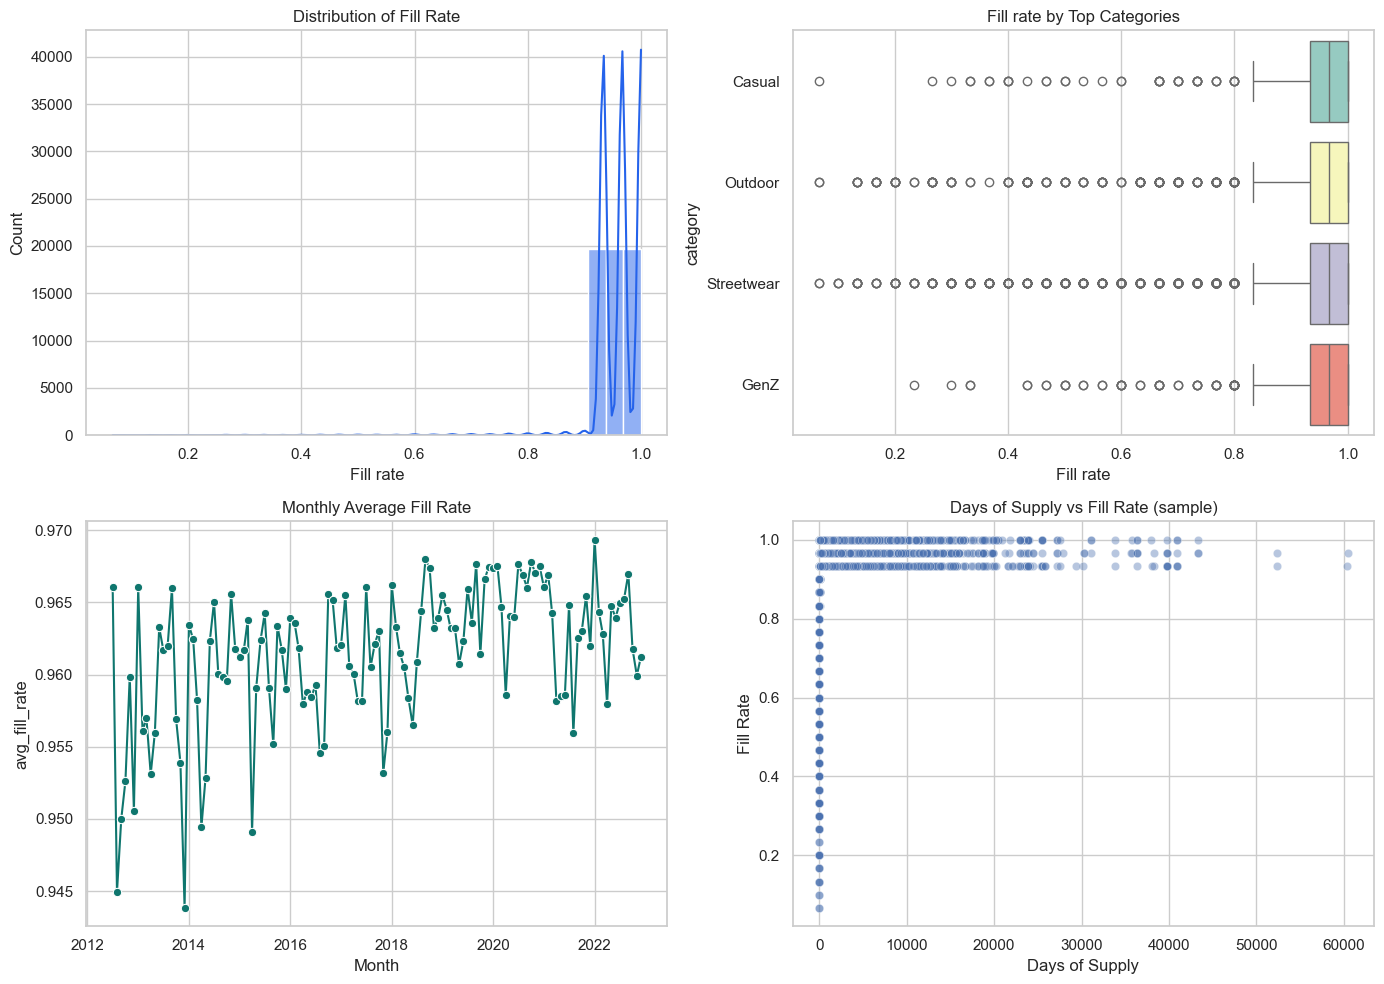


Category summary (sorted by stockout_rate):
  category  avg_fill_rate  stockout_rate  overstock_rate  median_days_supply
      GenZ       0.961718       0.682927        0.716303               210.0
   Outdoor       0.962705       0.673492        0.798527               300.0
Streetwear       0.960248       0.673211        0.749259               219.0
    Casual       0.961823       0.662004        0.725949               195.0

Sample SKUs flagged for review (low fill_rate):


,product_id,product_name,category,mean_fill_rate
505,720,HanoiStreet RP-08,Outdoor,0.544467
504,719,HanoiStreet RP-07,Outdoor,0.555567
800,1177,MekongFit UE-13,Streetwear,0.575000
474,668,SaigonFlex UC-33,Streetwear,0.775000
263,421,SaigonFlex UM-26,Streetwear,0.783350



Sample SKUs flagged for review (high stockout_days):


,product_id,product_name,category,mean_stockout_days
505,720,HanoiStreet RP-08,Outdoor,13.666667
504,719,HanoiStreet RP-07,Outdoor,13.333333
800,1177,MekongFit UE-13,Streetwear,12.750000
474,668,SaigonFlex UC-33,Streetwear,6.750000
263,421,SaigonFlex UM-26,Streetwear,6.500000


In [18]:
# Inventory analysis: distribution, category breakdown, trends and actionable lists
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')
base = Path('cleaned_data')
inv = pd.read_csv(base / 'cleaned_inventory.csv', parse_dates=['snapshot_date'])

# Quick metrics
total_rows = len(inv)
stockout_rate = inv['stockout_flag'].mean()
overstock_rate = inv['overstock_flag'].mean()
avg_fill_rate = inv['fill_rate'].mean()
avg_days_of_supply = inv['days_of_supply'].median()

print('Inventory snapshot rows:', total_rows)
print(f'Stockout rate (rows): {stockout_rate:.2%}')
print(f'Overstock rate (rows): {overstock_rate:.2%}')
print(f'Average fill_rate: {avg_fill_rate:.3f}')
print(f'Median days_of_supply: {avg_days_of_supply:.1f}')

# Top problem SKUs by average stockout_days and low fill_rate
sku_agg = inv.groupby(['product_id','product_name','category'], as_index=False).agg(
    mean_fill_rate=('fill_rate','mean'),
    mean_stockout_days=('stockout_days','mean'),
    median_days_supply=('days_of_supply','median'),
    rows=('snapshot_date','count')
)

low_fill = sku_agg.sort_values('mean_fill_rate').head(10)
high_stockout = sku_agg.sort_values('mean_stockout_days', ascending=False).head(10)

print('\nTop 10 SKUs with lowest avg fill_rate:')
print(low_fill[['product_id','product_name','category','mean_fill_rate']].to_string(index=False))
print('\nTop 10 SKUs with highest avg stockout_days:')
print(high_stockout[['product_id','product_name','category','mean_stockout_days']].to_string(index=False))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# 1) Fill rate distribution
sns.histplot(inv['fill_rate'].dropna(), bins=30, kde=True, ax=axes[0,0], color='#2563eb')
axes[0,0].set_title('Distribution of Fill Rate')
axes[0,0].set_xlabel('Fill rate')

# 2) Fill rate by category (top categories)
top_cats = inv['category'].value_counts().head(8).index.tolist()
cat_df = inv[inv['category'].isin(top_cats)]
sns.boxplot(data=cat_df, x='fill_rate', y='category', ax=axes[0,1], palette='Set3')
axes[0,1].set_title('Fill rate by Top Categories')
axes[0,1].set_xlabel('Fill rate')

# 3) Trend: monthly average fill_rate
inv['month'] = inv['snapshot_date'].dt.to_period('M').dt.to_timestamp()
monthly = inv.groupby('month', as_index=False).agg(avg_fill_rate=('fill_rate','mean'), stockout_rate=('stockout_flag','mean'))
sns.lineplot(data=monthly, x='month', y='avg_fill_rate', marker='o', ax=axes[1,0], color='#0f766e')
axes[1,0].set_title('Monthly Average Fill Rate')
axes[1,0].set_xlabel('Month')

# 4) Scatter days_of_supply vs fill_rate
sns.scatterplot(data=inv.sample(frac=0.5, random_state=1), x='days_of_supply', y='fill_rate', alpha=0.4, ax=axes[1,1])
axes[1,1].set_title('Days of Supply vs Fill Rate (sample)')
axes[1,1].set_xlabel('Days of Supply')
axes[1,1].set_ylabel('Fill Rate')

plt.tight_layout()
plt.show()

# Category-level summary table
cat_summary = inv.groupby('category', as_index=False).agg(
    avg_fill_rate=('fill_rate','mean'),
    stockout_rate=('stockout_flag','mean'),
    overstock_rate=('overstock_flag','mean'),
    median_days_supply=('days_of_supply','median')
).sort_values('stockout_rate', ascending=False)

print('\nCategory summary (sorted by stockout_rate):')
print(cat_summary.head(12).to_string(index=False))

# Export short lists for operator actions (kept in memory—no files)
action_low_fill = low_fill[['product_id','product_name','category','mean_fill_rate']]
action_high_stockout = high_stockout[['product_id','product_name','category','mean_stockout_days']]

# Display small samples
print('\nSample SKUs flagged for review (low fill_rate):')
display(action_low_fill.head())
print('\nSample SKUs flagged for review (high stockout_days):')
display(action_high_stockout.head())


## Inventory Insights & Operational Solutions

**Key insights (from visualizations above):**
- High-level metrics: stockout rate, overstock rate and average fill rate are printed above; these give a quick health check.
- Fill rate distribution: shows whether many SKUs are under-served (low fill_rate) or whether fill is generally healthy.
- Category risk: categories with high `stockout_rate` should be prioritized for replenishment and vendor review.
- SKU-level flags: lists of SKUs with low average `fill_rate` or high `stockout_days` are generated for operational follow-up.

**Actionable solutions:**
- Short-term (operational):
  - Run immediate replenishment for SKUs in `action_high_stockout` and `action_low_fill` (top 50) to reduce customer-facing stockouts.
  - Implement temporary allocation caps or pull from nearby DCs for SKUs with very low `fill_rate`.
- Mid-term (tactical):
  - Adjust reorder points / safety stock for categories with consistently high `stockout_rate` (use median `days_of_supply` and sell-through to recalibrate).
  - Tighten vendor SLAs for vendors supplying SKUs with high `stockout_days` and low `fill_rate`.
- Strategic (process & analytics):
  - Build a weekly inventory dashboard tracking `p50/p90 days_of_supply`, `fill_rate` and `stockout_rate` by category and vendor.
  - Use causal tests: A/B test raising safety stock for a cohort of SKUs vs control to measure impact on sales and holding costs.

If you want, I can: (A) limit `action_high_stockout` / `action_low_fill` to top 50 and save as CSV, (B) add vendor-level breakdowns, or (C) tune reorder point suggestions automatically.

## Key Insights từ cleaned_data (tổng hợp từ cell phân tích phía trên)



### 4) Chiết khấu và giá trị đơn hàng
- Insight: Discount rate khoảng 4.56%, AOV khoảng 24,238.
- Cách đọc từ cell: Tính tổng `discount_amount` trên tổng giá trị hàng trước giảm (`line_gross`), và AOV = tổng `line_net` / số đơn.
- Ý nghĩa: Có thể tối ưu chính sách discount theo phân khúc sản phẩm/nguồn đơn để giữ AOV tốt hơn.

### 5) Chất lượng sau bán và trải nghiệm
- Insight: Rating trung bình khoảng 3.94; low-rating (<=2) khoảng 13.09%; high-rating (>=4) khoảng 71.92%.
- Cách đọc từ cell: Phân phối `rating` từ `cleaned_reviews.csv`.
- Ý nghĩa: Mức hài lòng nhìn chung tốt nhưng vẫn có nhóm khách không hài lòng đủ lớn để tác động retention.


---
Gợi ý vận hành tiếp theo: tạo dashboard theo tuần cho 5 KPI trọng yếu gồm Gross margin rate, Return rate, Delivery p90, Orders/1k sessions, và Efficiency index theo kênh để theo dõi tác động cải tiến.

additional insight

## Biểu đồ insight khách mua hàng theo độ tuổi, giới tính và kênh biết đến

Cell dưới đây tập trung vào **khách đã phát sinh đơn hàng** (được xác định từ bảng `orders`), sau đó phân tích phân bố theo:
- `gender`
- `age_group`
- `acquisition_channel`

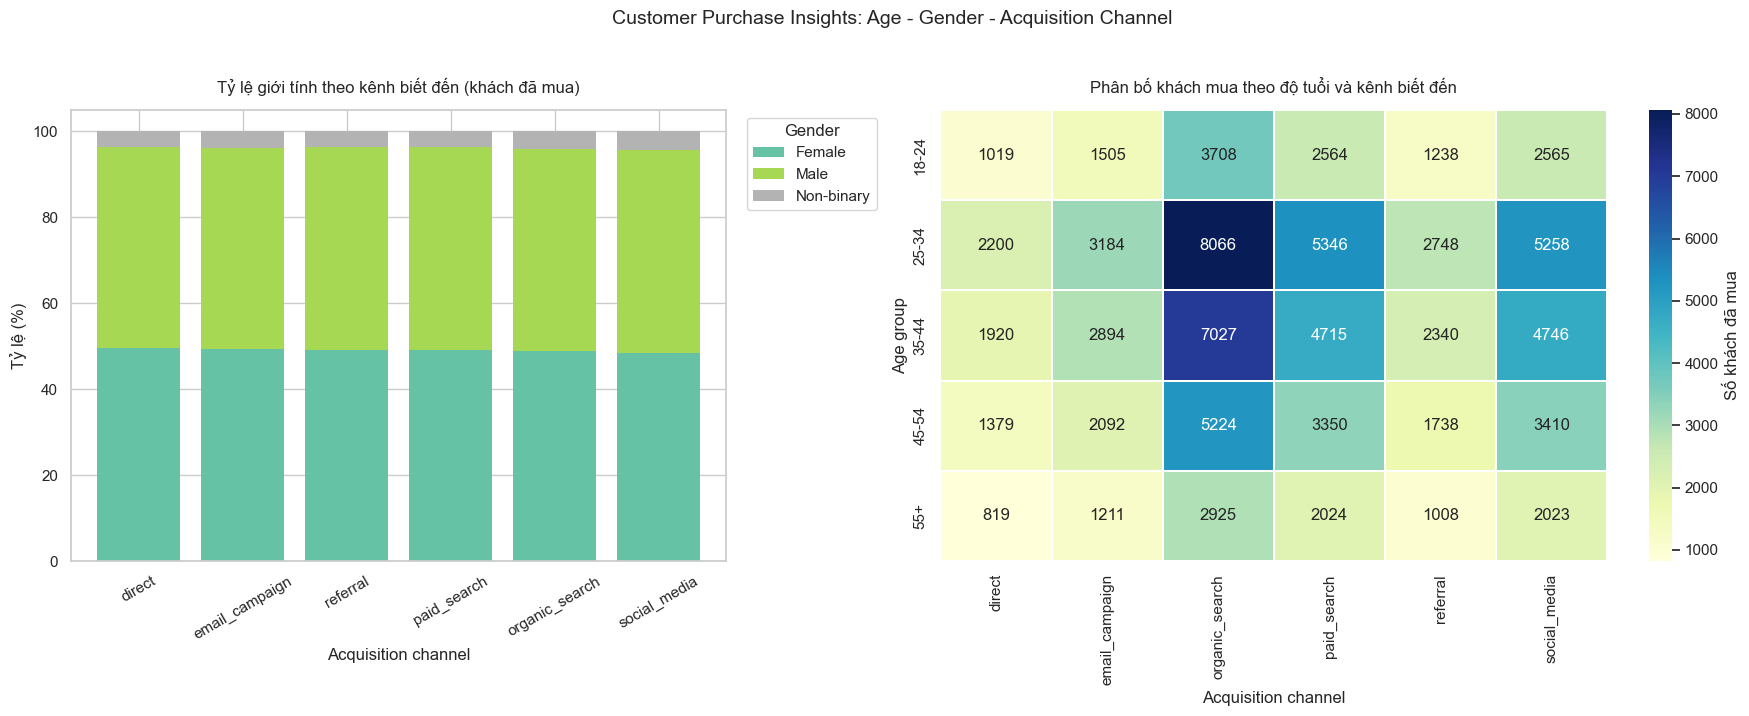

Kênh mang khách mua lớn nhất: organic_search (29.86%)

Top 3 nhóm tuổi khách mua:
age_group
25-34     29.7%
35-44     26.2%
45-54    19.05%
Name: proportion, dtype: str

Tỷ lệ giới tính tổng thể (khách đã mua):
gender
Female        48.97%
Male          47.07%
Non-binary     3.95%
Name: proportion, dtype: str


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Chỉ lấy khách đã mua hàng
buyer_ids = set(orders['customer_id'].dropna().unique())
buyers = customers[customers['customer_id'].isin(buyer_ids)].copy()

# Chuẩn hóa nhẹ để tránh lỗi thiếu dữ liệu
buyers['gender'] = buyers['gender'].fillna('Unknown')
buyers['age_group'] = buyers['age_group'].fillna('Unknown')
buyers['acquisition_channel'] = buyers['acquisition_channel'].fillna('Unknown')

# Sắp thứ tự nhóm tuổi để dễ đọc biểu đồ
age_order = ['<18', '18-24', '25-34', '35-44', '45-54', '55-64', '65+', 'Unknown']
existing_age_order = [a for a in age_order if a in buyers['age_group'].unique()]
remaining_ages = [a for a in buyers['age_group'].unique() if a not in existing_age_order]
final_age_order = existing_age_order + sorted(remaining_ages)

# 2) Bảng tỷ lệ giới tính trong từng acquisition channel (100% stacked)
channel_gender = pd.crosstab(buyers['acquisition_channel'], buyers['gender'])
channel_gender_pct = channel_gender.div(channel_gender.sum(axis=1), axis=0) * 100
channel_gender_pct = channel_gender_pct.sort_values(by=list(channel_gender_pct.columns), ascending=False)

# 3) Heatmap số lượng khách theo age_group x acquisition_channel
age_channel = pd.crosstab(buyers['age_group'], buyers['acquisition_channel'])
age_channel = age_channel.reindex(final_age_order).fillna(0)

# 4) Vẽ biểu đồ
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [1.1, 1.4]})

# Left: stacked bar chart
channel_gender_pct.plot(
    kind='bar',
    stacked=True,
    ax=axes[0],
    colormap='Set2',
    width=0.8,
    edgecolor='none'
)
axes[0].set_title('Tỷ lệ giới tính theo kênh biết đến (khách đã mua)', fontsize=12, pad=12)
axes[0].set_xlabel('Acquisition channel')
axes[0].set_ylabel('Tỷ lệ (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Gender', bbox_to_anchor=(1.02, 1), loc='upper left')

# Right: heatmap
sns.heatmap(
    age_channel,
    cmap='YlGnBu',
    linewidths=0.3,
    linecolor='white',
    annot=True,
    fmt='.0f',
    cbar_kws={'label': 'Số khách đã mua'},
    ax=axes[1]
)
axes[1].set_title('Phân bố khách mua theo độ tuổi và kênh biết đến', fontsize=12, pad=12)
axes[1].set_xlabel('Acquisition channel')
axes[1].set_ylabel('Age group')

plt.suptitle('Customer Purchase Insights: Age - Gender - Acquisition Channel', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 5) In nhanh vài insight định lượng
top_channel = buyers['acquisition_channel'].value_counts(normalize=True).head(1)
print('Kênh mang khách mua lớn nhất:', top_channel.index[0], f"({top_channel.iloc[0]:.2%})")

top_age = buyers['age_group'].value_counts(normalize=True).head(3)
print('\nTop 3 nhóm tuổi khách mua:')
print((top_age * 100).round(2).astype(str) + '%')

gender_share = buyers['gender'].value_counts(normalize=True)
print('\nTỷ lệ giới tính tổng thể (khách đã mua):')
print((gender_share * 100).round(2).astype(str) + '%')

## Brief Summary - Customer Insights

1. Nhóm khách mua chủ lực là 25-34, tiếp theo là 35-44 và 45-54.
Điều này cho thấy tệp khách trưởng thành trẻ đang đóng góp lớn nhất cho nhu cầu mua hàng.

2. Cơ cấu giới tính của khách mua khá cân bằng.
Female khoảng 48.97%, Male khoảng 47.07%, Non-binary khoảng 3.95%, vì vậy thông điệp marketing nên mang tính bao phủ thay vì thiên lệch giới.

3. Kênh mang khách mua lớn nhất là organic_search, sau đó là social_media và paid_search.
SEO và nội dung tìm kiếm tự nhiên đang là nguồn khách ổn định nhất.

## Khách hàng đến từ đâu? (Địa lý + nguồn kênh)

Phần này phân tích khách **đã mua hàng** theo:
- Khu vực địa lý: `region`, `city`
- Nguồn mang khách đến: `acquisition_channel` (hồ sơ khách) và `order_source` (nguồn đơn đầu tiên)

=== TOP REGION (khách đã mua) ===
region_final
East       49.55%
Central    34.11%
West       16.33%
Name: proportion, dtype: str

=== TOP CITY (khách đã mua) ===
city_final
Cam Pha        3.81%
Thai Nguyen     3.7%
Phu Ly         3.63%
Ha Long         3.6%
Bac Giang      3.59%
Son Tay        3.58%
Hai Phong      3.56%
Hanoi          3.52%
Nam Dinh       3.52%
Viet Tri       3.51%
Name: proportion, dtype: str

=== TOP FIRST ORDER SOURCE ===
order_source
organic_search    28.37%
paid_search       21.73%
social_media      19.98%
email_campaign    12.11%
referral           9.97%
direct             7.85%
Name: proportion, dtype: str

=== TOP ACQUISITION CHANNEL ===
acquisition_channel
organic_search    29.86%
social_media      19.95%
paid_search       19.94%
email_campaign    12.06%
referral          10.05%
direct             8.13%
Name: proportion, dtype: str


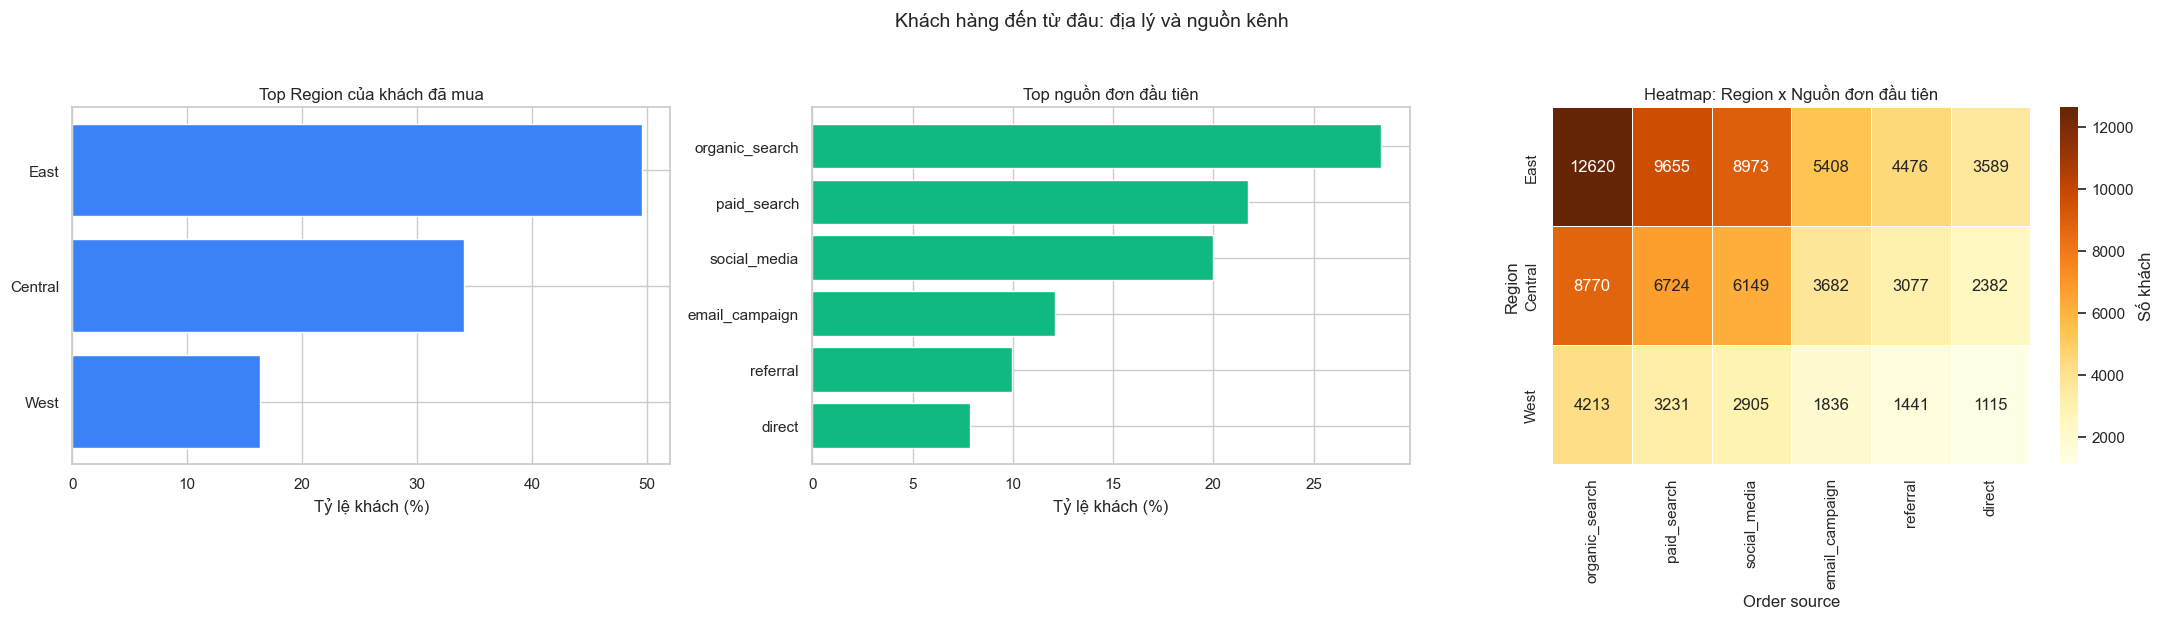

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load bảng geography để map zip -> region/city
geography = pd.read_csv(base / 'cleaned_geography.csv')

# 1) Lấy tệp khách đã mua
buyer_order_counts = orders.groupby('customer_id', as_index=False)['order_id'].count().rename(columns={'order_id': 'order_count'})
buyers_geo = customers.merge(buyer_order_counts, on='customer_id', how='inner')

# 2) Gắn thông tin địa lý theo zip
buyers_geo = buyers_geo.merge(
    geography[['zip', 'region', 'city']].drop_duplicates(subset=['zip']),
    on='zip',
    how='left',
    suffixes=('', '_geo')
)

# Ưu tiên city/region từ geography nếu có
buyers_geo['city_final'] = buyers_geo['city_geo'].fillna(buyers_geo['city'])
buyers_geo['region_final'] = buyers_geo['region'].fillna('Unknown')

# 3) Nguồn đơn đầu tiên của khách
orders_tmp = orders.copy()
orders_tmp['order_date'] = pd.to_datetime(orders_tmp['order_date'])
first_orders = orders_tmp.sort_values('order_date').drop_duplicates('customer_id')
first_orders = first_orders[['customer_id', 'order_source']]

buyers_geo = buyers_geo.merge(first_orders, on='customer_id', how='left')
buyers_geo['order_source'] = buyers_geo['order_source'].fillna('Unknown')
buyers_geo['acquisition_channel'] = buyers_geo['acquisition_channel'].fillna('Unknown')

# 4) Bảng tóm tắt
region_share = buyers_geo['region_final'].value_counts(normalize=True)
city_share = buyers_geo['city_final'].value_counts(normalize=True)
source_share = buyers_geo['order_source'].value_counts(normalize=True)
acq_share = buyers_geo['acquisition_channel'].value_counts(normalize=True)

print('=== TOP REGION (khách đã mua) ===')
print((region_share.head(8) * 100).round(2).astype(str) + '%')

print('\n=== TOP CITY (khách đã mua) ===')
print((city_share.head(10) * 100).round(2).astype(str) + '%')

print('\n=== TOP FIRST ORDER SOURCE ===')
print((source_share.head(8) * 100).round(2).astype(str) + '%')

print('\n=== TOP ACQUISITION CHANNEL ===')
print((acq_share.head(8) * 100).round(2).astype(str) + '%')

# 5) Trực quan
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# (a) Top region
region_plot = (region_share.head(6) * 100).sort_values()
axes[0].barh(region_plot.index, region_plot.values, color='#3b82f6')
axes[0].set_title('Top Region của khách đã mua')
axes[0].set_xlabel('Tỷ lệ khách (%)')

# (b) Top first order source
source_plot = (source_share.head(6) * 100).sort_values()
axes[1].barh(source_plot.index, source_plot.values, color='#10b981')
axes[1].set_title('Top nguồn đơn đầu tiên')
axes[1].set_xlabel('Tỷ lệ khách (%)')

# (c) Heatmap region x order_source
region_source = pd.crosstab(buyers_geo['region_final'], buyers_geo['order_source'])
top_regions = region_source.sum(axis=1).sort_values(ascending=False).head(6).index
top_sources = region_source.sum(axis=0).sort_values(ascending=False).head(6).index
heat_data = region_source.loc[top_regions, top_sources]

sns.heatmap(
    heat_data,
    annot=True,
    fmt='d',
    cmap='YlOrBr',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Số khách'},
    ax=axes[2]
)
axes[2].set_title('Heatmap: Region x Nguồn đơn đầu tiên')
axes[2].set_xlabel('Order source')
axes[2].set_ylabel('Region')

plt.suptitle('Khách hàng đến từ đâu: địa lý và nguồn kênh', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## Actionable Recommendations theo vùng và kênh

### 1) Ưu tiên theo vùng
- **East (49.55% khách):** vùng trọng điểm, nên ưu tiên ngân sách performance và tồn kho cho SKU bán chạy.
- **Central (34.11% khách):** vùng duy trì tăng trưởng ổn định, tập trung campaign giữ chân và mua lại.
- **West (16.33% khách):** vùng có dư địa mở rộng, phù hợp với ưu đãi first purchase và second purchase.

### 2) Ưu tiên theo kênh
- **organic_search (28.37%):** tiếp tục đầu tư SEO và tối ưu landing page cho nhóm sản phẩm chủ lực.
- **paid_search (21.73%):** tách rõ brand/non-brand, ưu tiên keyword có chuyển đổi cao ở East và Central.
- **social_media (19.98%):** đẩy creative cho nhóm tuổi 25-44, tăng UGC và social proof.
- **email_campaign (12.11%):** tối ưu subject line, phân khúc tệp, và tự động hóa abandoned cart/re-engagement.
- **referral (9.97%) và direct (7.85%):** dùng chương trình giới thiệu và loyalty để tăng traffic chất lượng cao.

### 3) Theo city trọng điểm
- Tập trung localize thông điệp cho các city như **Cam Pha, Thai Nguyen, Phu Ly, Ha Long, Bac Giang**.
- Rà soát tồn kho theo city để hạn chế out-of-stock ở nhóm sản phẩm bán chạy.

### 4) KPI nên theo dõi hàng tuần
- Số khách mới theo **region** và theo **source**.
- **CAC** theo từng source, đặc biệt với paid_search, social_media và email.
- **CVR** theo source và theo vùng.
- **Repeat rate** theo city trọng điểm.
- **Return rate do wrong_size** theo region/city.

### 5) Mục tiêu 6-8 tuần
- Tăng tỷ trọng khách mới từ **West** thêm **2-3 điểm %**.
- Tăng conversion từ **social_media** và **paid_search** tối thiểu **10%**.
- Giảm tỷ lệ trả hàng do **sai size** tối thiểu **10%** ở top city.

## Web Traffic Insights

Phần này tập trung hoàn toàn vào `cleaned_web_traffic.csv` để xem traffic đến từ đâu, biến động theo thời gian như thế nào, và chất lượng phiên truy cập ra sao.

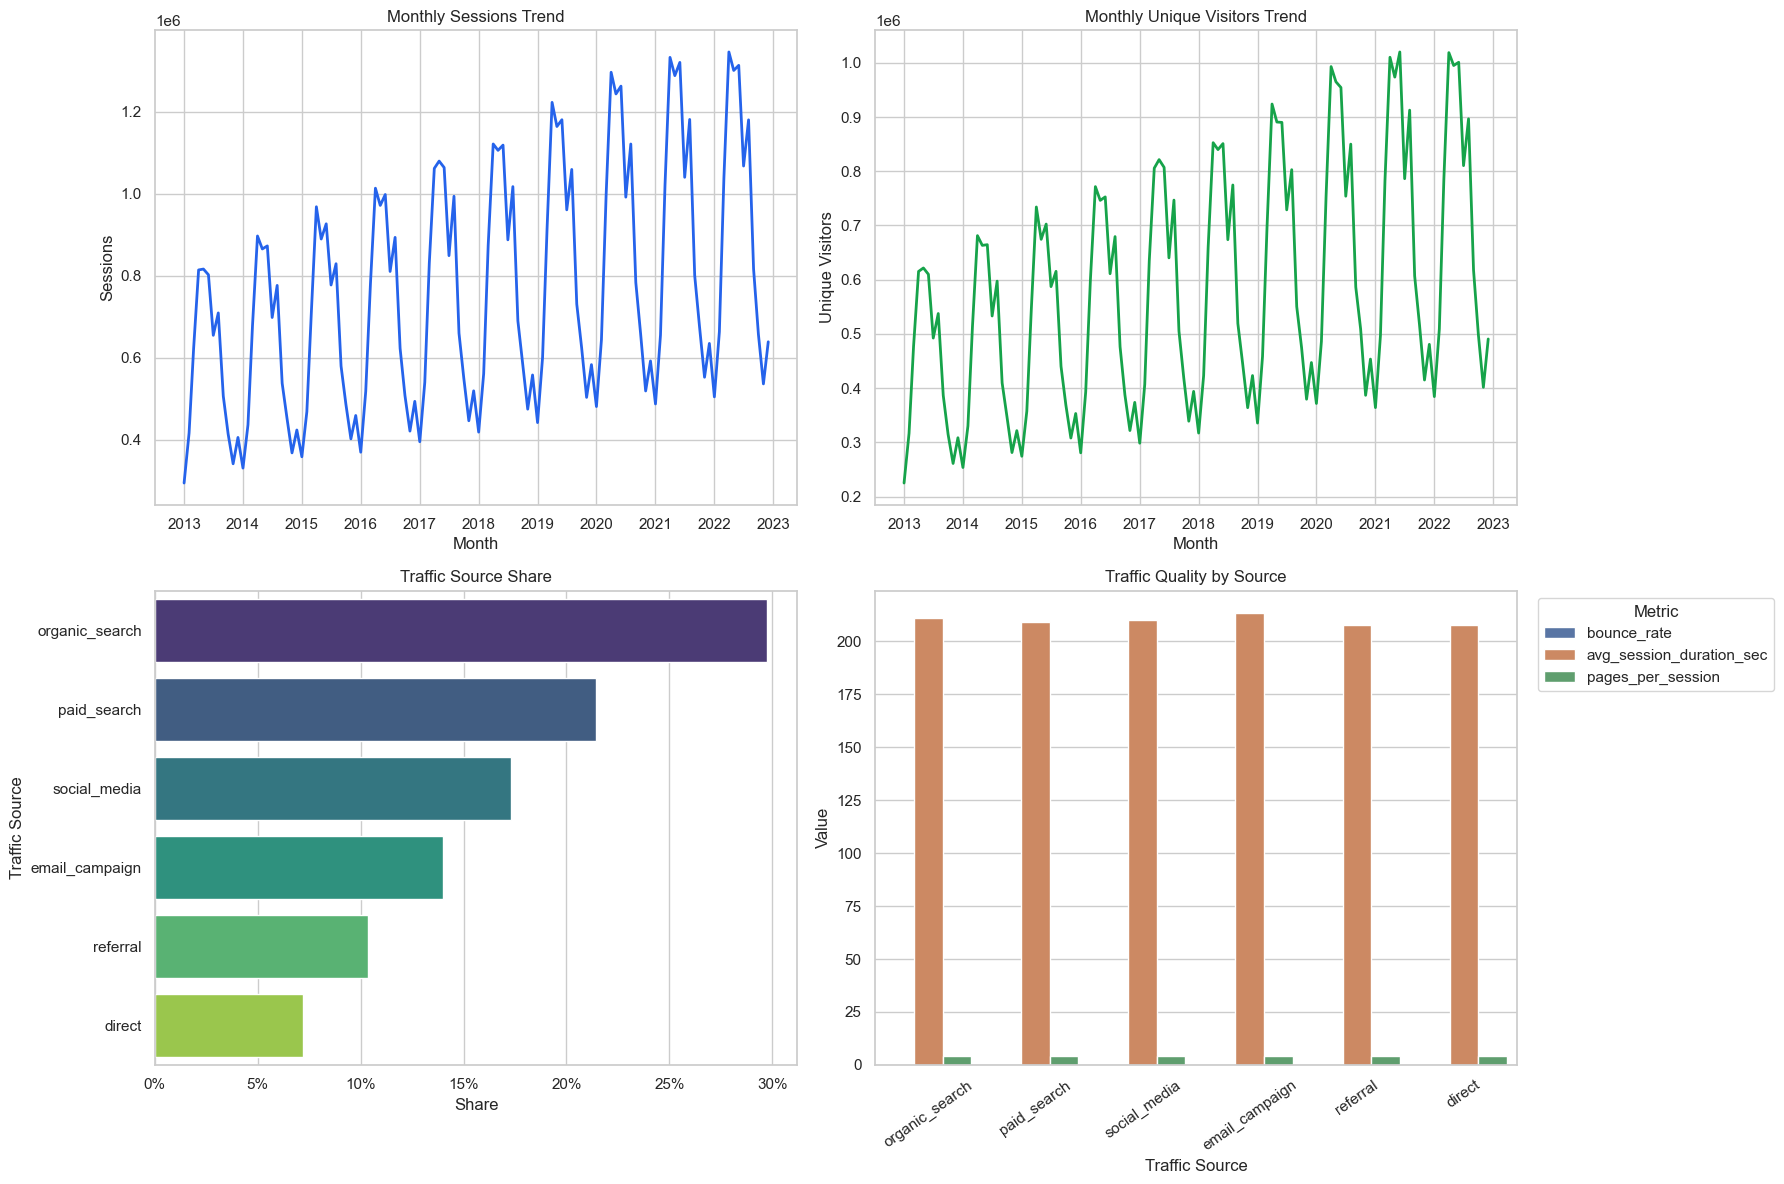

=== WEB TRAFFIC INSIGHTS ===
Date range: 2013-01-01 to 2022-12-31
Total sessions: 91,452,537
Total unique visitors: 69,502,689
Average bounce rate: 0.45%
Average session duration: 210.28 sec
Average pages per session: 4.34
Correlation sessions vs unique visitors: 0.992

Traffic source share:
traffic_source
organic_search    29.74%
paid_search       21.43%
social_media      17.29%
email_campaign    13.99%
referral          10.36%
direct             7.19%
Name: share, dtype: str

Peak month by sessions: 2022-04
Lowest month by sessions: 2013-01


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

traffic_df = traffic.copy()
traffic_df['date'] = pd.to_datetime(traffic_df['date'])
traffic_df['month'] = traffic_df['date'].dt.to_period('M').astype(str)
traffic_df['pages_per_session'] = traffic_df['page_views'] / traffic_df['sessions']

monthly = traffic_df.groupby('month', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean')
)
monthly['pages_per_session'] = monthly['page_views'] / monthly['sessions']
monthly['month_dt'] = pd.to_datetime(monthly['month'])
monthly = monthly.sort_values('month_dt')

source = traffic_df.groupby('traffic_source', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    bounce_rate=('bounce_rate', 'mean'),
    avg_session_duration_sec=('avg_session_duration_sec', 'mean'),
    pages_per_session=('pages_per_session', 'mean')
).sort_values('sessions', ascending=False)
source['share'] = source['sessions'] / source['sessions'].sum()

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Monthly sessions trend
sns.lineplot(data=monthly, x='month_dt', y='sessions', ax=axes[0, 0], color='#2563eb', linewidth=2)
axes[0, 0].set_title('Monthly Sessions Trend')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Sessions')

# 2) Monthly unique visitors trend
sns.lineplot(data=monthly, x='month_dt', y='unique_visitors', ax=axes[0, 1], color='#16a34a', linewidth=2)
axes[0, 1].set_title('Monthly Unique Visitors Trend')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Unique Visitors')

# 3) Traffic source share
source_plot = source.copy()
sns.barplot(
    data=source_plot,
    y='traffic_source',
    x='share',
    hue='traffic_source',
    dodge=False,
    palette='viridis',
    ax=axes[1, 0],
    legend=False
)
axes[1, 0].set_title('Traffic Source Share')
axes[1, 0].set_xlabel('Share')
axes[1, 0].set_ylabel('Traffic Source')
axes[1, 0].xaxis.set_major_formatter(lambda x, pos: f'{x:.0%}')

# 4) Quality metrics by source
quality = source.melt(id_vars='traffic_source', value_vars=['bounce_rate', 'avg_session_duration_sec', 'pages_per_session'], var_name='metric', value_name='value')
sns.barplot(data=quality, x='traffic_source', y='value', hue='metric', ax=axes[1, 1])
axes[1, 1].set_title('Traffic Quality by Source')
axes[1, 1].set_xlabel('Traffic Source')
axes[1, 1].set_ylabel('Value')
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

print('=== WEB TRAFFIC INSIGHTS ===')
print(f"Date range: {traffic_df['date'].min().date()} to {traffic_df['date'].max().date()}")
print(f"Total sessions: {traffic_df['sessions'].sum():,}")
print(f"Total unique visitors: {traffic_df['unique_visitors'].sum():,}")
print(f"Average bounce rate: {traffic_df['bounce_rate'].mean():.2%}")
print(f"Average session duration: {traffic_df['avg_session_duration_sec'].mean():.2f} sec")
print(f"Average pages per session: {(traffic_df['page_views'] / traffic_df['sessions']).mean():.2f}")
print(f"Correlation sessions vs unique visitors: {traffic_df['sessions'].corr(traffic_df['unique_visitors']):.3f}")
print('\nTraffic source share:')
print((source.set_index('traffic_source')['share'] * 100).round(2).astype(str) + '%')
print('\nPeak month by sessions:', monthly.loc[monthly['sessions'].idxmax(), 'month'])
print('Lowest month by sessions:', monthly.loc[monthly['sessions'].idxmin(), 'month'])

## Brief Summary - Web Traffic

- Traffic tăng mạnh theo thời gian và đạt đỉnh vào 2022-04, nguyên nhân chính có thể là do dịch covid 19 bùng nổ, nhu cầu đặt hàng mua sắm online qua mạng càng ngày càng cao, cho thấy mức độ quan tâm ngày càng cao qua các năm.
- organic_search là nguồn traffic lớn nhất, sau đó là paid_search và social_media, nên SEO vẫn là kênh cốt lõi.
- Chất lượng traffic nhìn chung tốt: bounce rate thấp, session duration trung bình khoảng 210 giây và khoảng 4.34 pages/session.
- Sessions và unique visitors có tương quan rất cao, cho thấy traffic tăng thực sự đi kèm với lượng người dùng tăng.
- Tóm lại, web traffic đang có xu hướng tăng ổn định, với organic_search là nguồn đóng góp quan trọng nhất và là kênh nên ưu tiên duy trì, tối ưu.

## Sales Insights

Phần này phân tích riêng `cleaned_sales.csv` để xem doanh thu, COGS và gross margin biến động như thế nào theo thời gian.

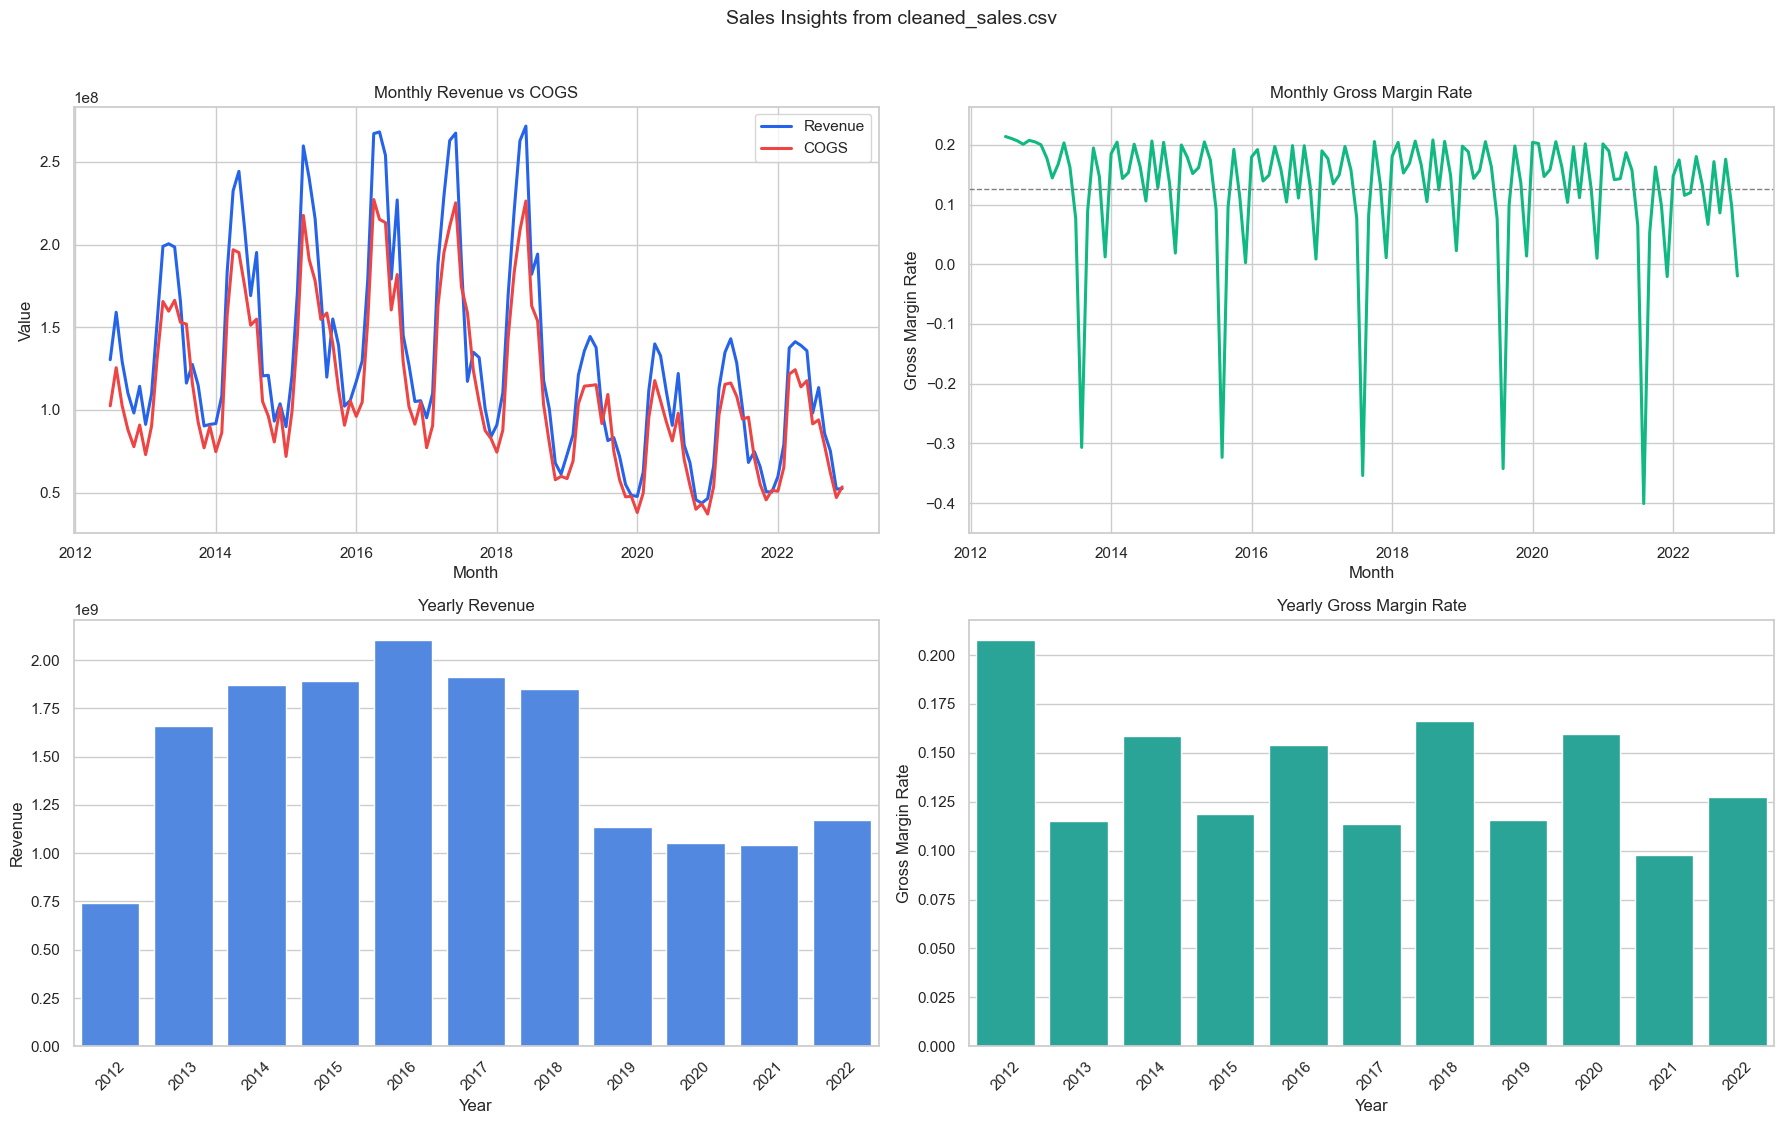

=== SALES INSIGHTS ===
Date range: 2012-07-04 to 2022-12-31
Total revenue: 16,430,476,585.53
Total COGS: 14,163,450,519.17
Total gross margin: 2,267,026,066.36
Overall gross margin rate: 13.80%
Average daily revenue: 4,286,584.03
Median daily revenue: 3,647,303.90
Revenue std dev: 2,624,840.20
Peak revenue month: 2018-06 (271,674,172.09)
Lowest revenue month: 2020-12 (43,671,563.77)
Peak gross margin rate month: 2012-07 (21.39%)
Lowest gross margin rate month: 2021-08 (-40.09%)


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sales_df = sales.copy()
sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df['month_dt'] = sales_df['Date'].dt.to_period('M').dt.to_timestamp()
sales_df['year'] = sales_df['Date'].dt.year
sales_df['gross_margin'] = sales_df['Revenue'] - sales_df['COGS']
sales_df['gross_margin_rate'] = sales_df['gross_margin'] / sales_df['Revenue']

monthly = sales_df.groupby('month_dt', as_index=False).agg(
    revenue=('Revenue', 'sum'),
    cogs=('COGS', 'sum'),
    gross_margin=('gross_margin', 'sum')
)
monthly['gross_margin_rate'] = monthly['gross_margin'] / monthly['revenue']
monthly = monthly.sort_values('month_dt')

yearly = sales_df.groupby('year', as_index=False).agg(
    revenue=('Revenue', 'sum'),
    cogs=('COGS', 'sum'),
    gross_margin=('gross_margin', 'sum')
)
yearly['gross_margin_rate'] = yearly['gross_margin'] / yearly['revenue']

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 11))

# Monthly revenue and COGS
axes[0, 0].plot(monthly['month_dt'], monthly['revenue'], label='Revenue', color='#2563eb', linewidth=2.2)
axes[0, 0].plot(monthly['month_dt'], monthly['cogs'], label='COGS', color='#ef4444', linewidth=2.2)
axes[0, 0].set_title('Monthly Revenue vs COGS')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()

# Monthly gross margin rate
axes[0, 1].plot(monthly['month_dt'], monthly['gross_margin_rate'], color='#10b981', linewidth=2.2)
axes[0, 1].axhline(monthly['gross_margin_rate'].mean(), color='gray', linestyle='--', linewidth=1)
axes[0, 1].set_title('Monthly Gross Margin Rate')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Gross Margin Rate')
axes[0, 1].set_ylim(monthly['gross_margin_rate'].min() - 0.05, monthly['gross_margin_rate'].max() + 0.05)

# Yearly revenue
sns.barplot(data=yearly, x='year', y='revenue', ax=axes[1, 0], color='#3b82f6')
axes[1, 0].set_title('Yearly Revenue')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Revenue')
axes[1, 0].tick_params(axis='x', rotation=45)

# Yearly gross margin rate
sns.barplot(data=yearly, x='year', y='gross_margin_rate', ax=axes[1, 1], color='#14b8a6')
axes[1, 1].set_title('Yearly Gross Margin Rate')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Gross Margin Rate')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.suptitle('Sales Insights from cleaned_sales.csv', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('=== SALES INSIGHTS ===')
print(f"Date range: {sales_df['Date'].min().date()} to {sales_df['Date'].max().date()}")
print(f"Total revenue: {sales_df['Revenue'].sum():,.2f}")
print(f"Total COGS: {sales_df['COGS'].sum():,.2f}")
print(f"Total gross margin: {sales_df['gross_margin'].sum():,.2f}")
print(f"Overall gross margin rate: {sales_df['gross_margin'].sum() / sales_df['Revenue'].sum():.2%}")
print(f"Average daily revenue: {sales_df['Revenue'].mean():,.2f}")
print(f"Median daily revenue: {sales_df['Revenue'].median():,.2f}")
print(f"Revenue std dev: {sales_df['Revenue'].std():,.2f}")
print(f"Peak revenue month: {monthly.loc[monthly['revenue'].idxmax(), 'month_dt'].strftime('%Y-%m')} ({monthly['revenue'].max():,.2f})")
print(f"Lowest revenue month: {monthly.loc[monthly['revenue'].idxmin(), 'month_dt'].strftime('%Y-%m')} ({monthly['revenue'].min():,.2f})")
print(f"Peak gross margin rate month: {monthly.loc[monthly['gross_margin_rate'].idxmax(), 'month_dt'].strftime('%Y-%m')} ({monthly['gross_margin_rate'].max():.2%})")
print(f"Lowest gross margin rate month: {monthly.loc[monthly['gross_margin_rate'].idxmin(), 'month_dt'].strftime('%Y-%m')} ({monthly['gross_margin_rate'].min():.2%})")

## Brief Summary - Sales Insights

- `cleaned_sales.csv` cho thấy doanh thu lớn nhưng biên lợi nhuận chưa ổn định, với gross margin rate toàn kỳ khoảng 13.80%.
- Doanh thu đạt đỉnh vào 2018-06 rồi giảm dần ở các năm sau, cho thấy tăng trưởng không duy trì đều trong dài hạn.
- Có nhiều giai đoạn gross margin rate biến động mạnh, thậm chí âm, nghĩa là chi phí đã vượt doanh thu ở một số thời điểm.
- Tóm lại, bài toán quan trọng nhất từ sales không chỉ là tăng revenue mà còn là kiểm soát COGS và ổn định gross margin.

## Merged Web Traffic + Orders Insights

Phần này ghép `cleaned_web_traffic.csv` với `cleaned_orders.csv` theo ngày để xem traffic có thực sự đi cùng số đơn hay không.

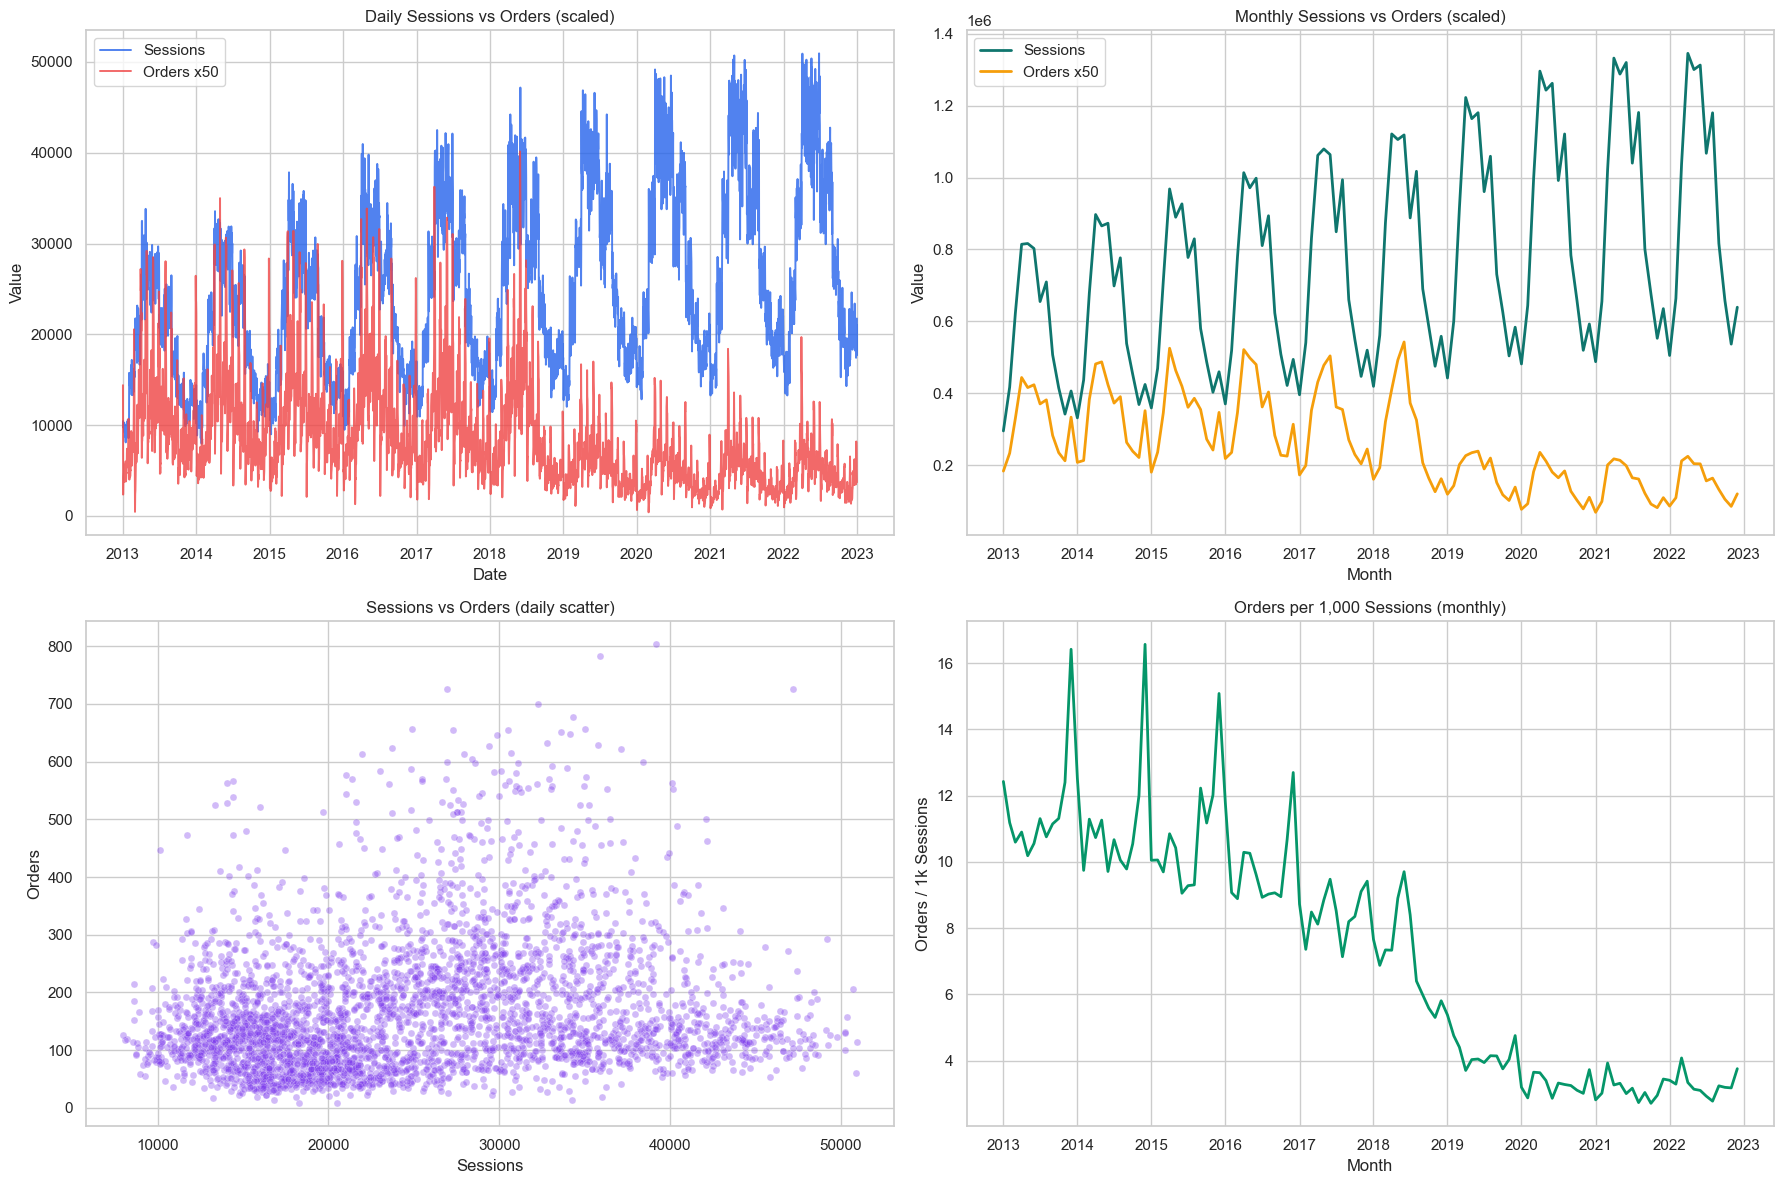

=== MERGED WEB TRAFFIC + ORDERS INSIGHTS ===
Days overlapped: 3,652
Correlation sessions vs orders (daily): 0.1909
Correlation unique visitors vs orders (daily): 0.1892
Average orders per 1k sessions: 7.36
Average orders per 1k visitors: 9.69
Monthly correlation sessions vs orders: 0.2827
Monthly correlation visitors vs orders: 0.2817
Peak order day: 2018-05-30 (803 orders)
Peak session day: 2022-06-26 (50947 sessions)
Peak monthly orders: 2018-06 (10851)
Peak monthly sessions: 2022-04 (1345666)


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Merge daily traffic with daily orders
traffic_orders_daily = pd.DataFrame({
    'order_date': pd.to_datetime(orders['order_date']),
    'order_id': orders['order_id']
}).groupby('order_date').agg(orders=('order_id', 'nunique'))

traffic_daily = pd.DataFrame({
    'date': pd.to_datetime(traffic_df['date']) if 'traffic_df' in globals() else pd.to_datetime(traffic['date']),
    'sessions': traffic_df['sessions'] if 'traffic_df' in globals() else traffic['sessions'],
    'unique_visitors': traffic_df['unique_visitors'] if 'traffic_df' in globals() else traffic['unique_visitors'],
    'page_views': traffic_df['page_views'] if 'traffic_df' in globals() else traffic['page_views']
}).groupby('date').agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum')
)

merged_daily = traffic_orders_daily.join(traffic_daily, how='inner').reset_index().rename(columns={'order_date': 'date'})
merged_daily['orders_per_1k_sessions'] = merged_daily['orders'] / merged_daily['sessions'] * 1000
merged_daily['orders_per_1k_visitors'] = merged_daily['orders'] / merged_daily['unique_visitors'] * 1000
merged_daily['month'] = merged_daily['date'].dt.to_period('M').dt.to_timestamp()

merged_monthly = merged_daily.groupby('month', as_index=False).agg(
    orders=('orders', 'sum'),
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum'),
    page_views=('page_views', 'sum')
)
merged_monthly['orders_per_1k_sessions'] = merged_monthly['orders'] / merged_monthly['sessions'] * 1000
merged_monthly['orders_per_1k_visitors'] = merged_monthly['orders'] / merged_monthly['unique_visitors'] * 1000

sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1) Daily orders vs sessions
axes[0, 0].plot(merged_daily['date'], merged_daily['sessions'], color='#2563eb', linewidth=1.4, alpha=0.8, label='Sessions')
axes[0, 0].plot(merged_daily['date'], merged_daily['orders'] * 50, color='#ef4444', linewidth=1.4, alpha=0.8, label='Orders x50')
axes[0, 0].set_title('Daily Sessions vs Orders (scaled)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()

# 2) Monthly orders vs sessions
axes[0, 1].plot(merged_monthly['month'], merged_monthly['sessions'], color='#0f766e', linewidth=2, label='Sessions')
axes[0, 1].plot(merged_monthly['month'], merged_monthly['orders'] * 50, color='#f59e0b', linewidth=2, label='Orders x50')
axes[0, 1].set_title('Monthly Sessions vs Orders (scaled)')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Value')
axes[0, 1].legend()

# 3) Scatter sessions vs orders
sns.scatterplot(data=merged_daily, x='sessions', y='orders', alpha=0.35, s=25, ax=axes[1, 0], color='#7c3aed')
axes[1, 0].set_title('Sessions vs Orders (daily scatter)')
axes[1, 0].set_xlabel('Sessions')
axes[1, 0].set_ylabel('Orders')

# 4) Conversion proxy over time
axes[1, 1].plot(merged_monthly['month'], merged_monthly['orders_per_1k_sessions'], color='#059669', linewidth=2)
axes[1, 1].set_title('Orders per 1,000 Sessions (monthly)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Orders / 1k Sessions')

plt.tight_layout()
plt.show()

print('=== MERGED WEB TRAFFIC + ORDERS INSIGHTS ===')
print(f"Days overlapped: {len(merged_daily):,}")
print(f"Correlation sessions vs orders (daily): {merged_daily['sessions'].corr(merged_daily['orders']):.4f}")
print(f"Correlation unique visitors vs orders (daily): {merged_daily['unique_visitors'].corr(merged_daily['orders']):.4f}")
print(f"Average orders per 1k sessions: {merged_daily['orders_per_1k_sessions'].mean():.2f}")
print(f"Average orders per 1k visitors: {merged_daily['orders_per_1k_visitors'].mean():.2f}")
print(f"Monthly correlation sessions vs orders: {merged_monthly['sessions'].corr(merged_monthly['orders']):.4f}")
print(f"Monthly correlation visitors vs orders: {merged_monthly['unique_visitors'].corr(merged_monthly['orders']):.4f}")
print(f"Peak order day: {merged_daily.loc[merged_daily['orders'].idxmax(), 'date'].date()} ({int(merged_daily['orders'].max())} orders)")
print(f"Peak session day: {merged_daily.loc[merged_daily['sessions'].idxmax(), 'date'].date()} ({int(merged_daily['sessions'].max())} sessions)")
print(f"Peak monthly orders: {merged_monthly.loc[merged_monthly['orders'].idxmax(), 'month'].strftime('%Y-%m')} ({int(merged_monthly['orders'].max())})")
print(f"Peak monthly sessions: {merged_monthly.loc[merged_monthly['sessions'].idxmax(), 'month'].strftime('%Y-%m')} ({int(merged_monthly['sessions'].max())})")

## Brief Summary - Merged Web Traffic + Orders

- Traffic tăng mạnh theo thời gian, nhưng số đơn không tăng tương ứng, nên traffic volume không phải là yếu tố quyết định duy nhất.
- Mối tương quan giữa sessions và orders chỉ ở mức thấp đến trung bình, cho thấy conversion funnel chưa đủ mạnh để biến traffic thành đơn hàng ổn định.
- Peak traffic rơi vào 2022-04, trong khi peak orders lại ở 2018-06, chứng tỏ đỉnh truy cập và đỉnh mua hàng không trùng nhau.
- Kết luận chính: nên tập trung cải thiện chất lượng traffic và conversion efficiency thay vì chỉ tăng lượt truy cập.

## Returns EDA — Phân tích chi tiết `cleaned_returns.csv`
Phân tích này tập trung vào: phân bố nguyên nhân trả hàng, tác động tài chính, theo danh mục sản phẩm và theo thời gian.

,return_reason,count,qty,refund_sum
4,wrong_size,13967,38042,1.766872e+08
1,defective,8020,22274,1.035991e+08
3,not_as_described,7035,19358,9.065319e+07
0,changed_mind,6931,19144,8.972176e+07
2,late_delivery,3986,10768,4.993721e+07


C:\Users\HP\AppData\Local\Temp\ipykernel_10116\2978765034.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=reason_cnt, x='return_reason', y='count', palette='tab10')


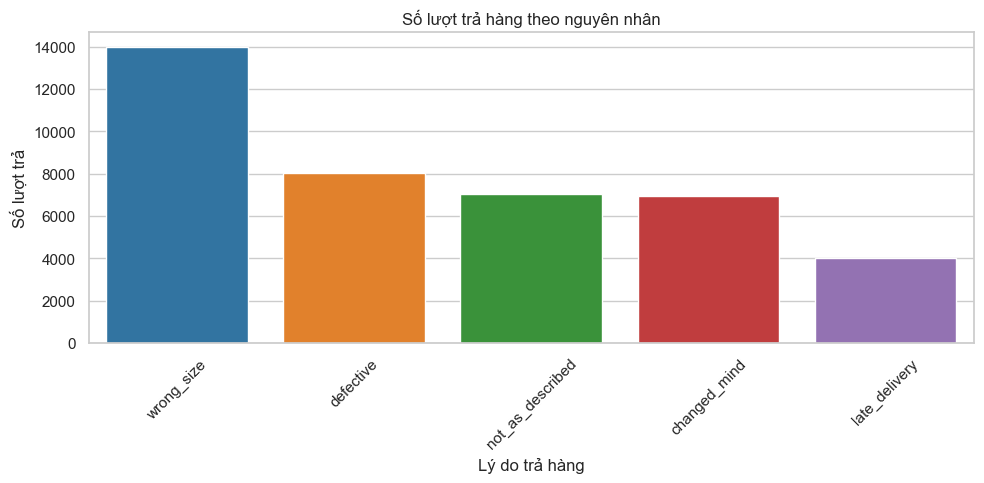

C:\Users\HP\AppData\Local\Temp\ipykernel_10116\2978765034.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=reason_cnt, x='return_reason', y='refund_sum', palette='rocket')


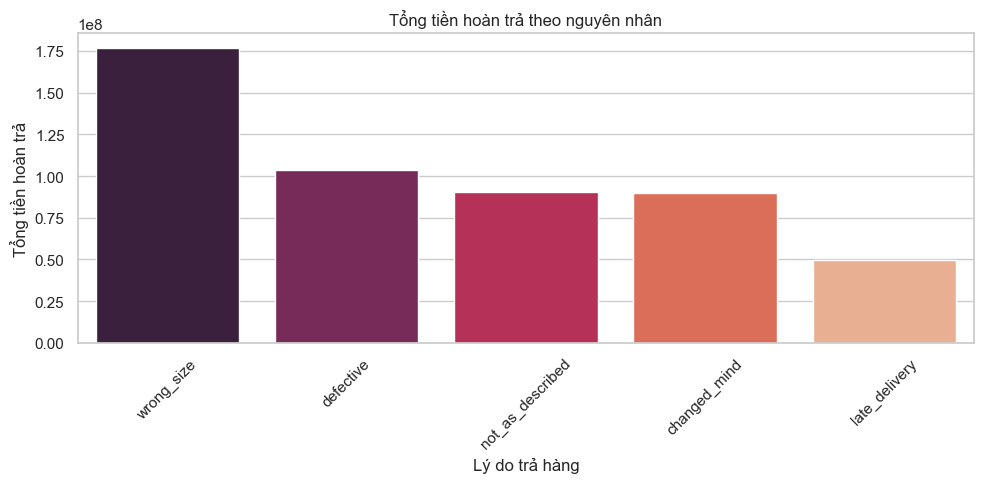

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
# outputs displayed inline in the notebook
base = Path('cleaned_data')
returns = pd.read_csv(base / 'cleaned_returns.csv', parse_dates=['return_date'])
products = pd.read_csv(base / 'cleaned_products.csv')
orders = pd.read_csv(base / 'cleaned_orders.csv', parse_dates=['order_date'])

# Summaries by reason
reason_cnt = returns.groupby('return_reason', as_index=False).agg(count=('return_id','count'), qty=('return_quantity','sum'), refund_sum=('refund_amount','sum')).sort_values('count', ascending=False)
display(reason_cnt)

# Bar plot: count by reason
plt.figure(figsize=(10,5))
ax = sns.barplot(data=reason_cnt, x='return_reason', y='count', palette='tab10')
ax.set_title('Số lượt trả hàng theo nguyên nhân')
ax.set_xlabel('Lý do trả hàng')
ax.set_ylabel('Số lượt trả')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar plot: refund amount by reason
plt.figure(figsize=(10,5))
ax = sns.barplot(data=reason_cnt, x='return_reason', y='refund_sum', palette='rocket')
ax.set_title('Tổng tiền hoàn trả theo nguyên nhân')
ax.set_xlabel('Lý do trả hàng')
ax.set_ylabel('Tổng tiền hoàn trả')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,category,count,qty,refund_sum
3,Streetwear,21799,59801,4.067082e+08
2,Outdoor,14720,40417,7.871751e+07
1,GenZ,2126,5869,1.114565e+07
0,Casual,1294,3499,1.402709e+07


C:\Users\HP\AppData\Local\Temp\ipykernel_10116\931778085.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_summary.head(10), x='count', y=prod_cat_col, palette='mako')


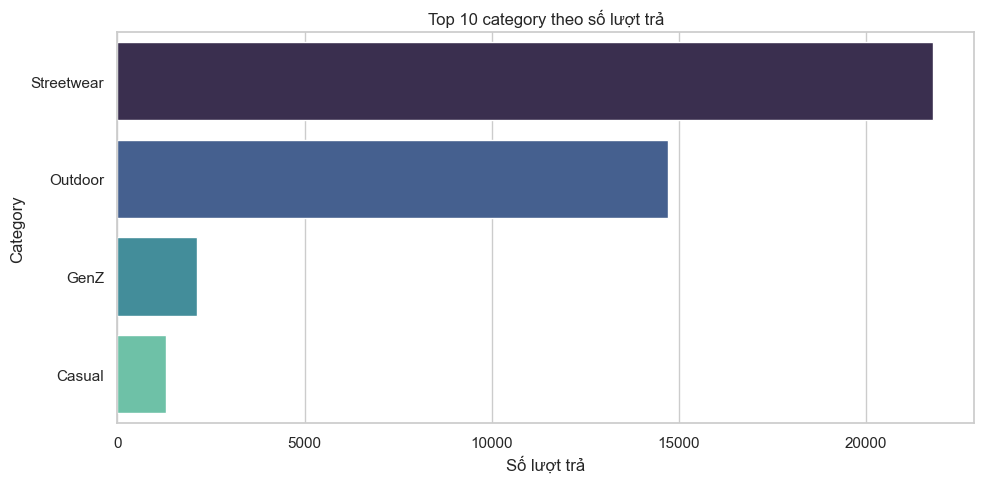

In [2]:
# Merge with products to get category-level view (if available)
prod_cat_col = None
if 'product_category' in products.columns:
    prod_cat_col = 'product_category'
elif 'category' in products.columns:
    prod_cat_col = 'category'

if prod_cat_col is not None:
    merged = returns.merge(products[['product_id', prod_cat_col]].drop_duplicates(), on='product_id', how='left')
    cat_summary = merged.groupby(prod_cat_col, as_index=False).agg(count=('return_id','count'), qty=('return_quantity','sum'), refund_sum=('refund_amount','sum')).sort_values('count', ascending=False)
    display(cat_summary.head(10))
    plt.figure(figsize=(10,5))
    sns.barplot(data=cat_summary.head(10), x='count', y=prod_cat_col, palette='mako')
    plt.title('Top 10 category theo số lượt trả')
    plt.xlabel('Số lượt trả')
    plt.ylabel('Category')
    plt.tight_layout()
    plt.show()
else:
    print('Không tìm thấy cột category trong products; bỏ qua phân tích theo danh mục.')


,month,count,refund_sum
0,2012-07-01,107,1566367.16
1,2012-08-01,393,4585187.41
2,2012-09-01,356,4141199.96
3,2012-10-01,334,4401616.95
4,2012-11-01,300,3774908.08


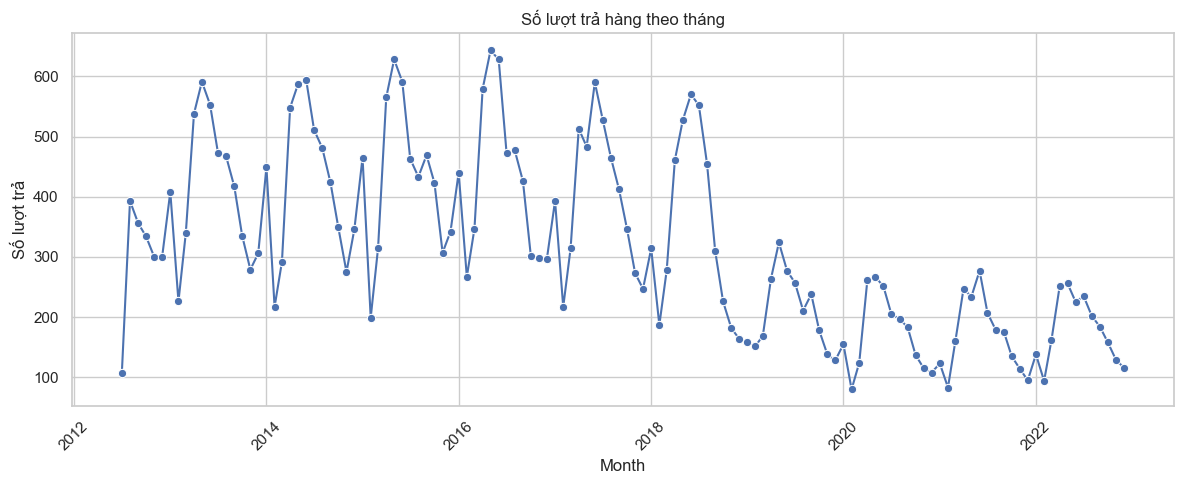

<Figure size 1200x600 with 0 Axes>

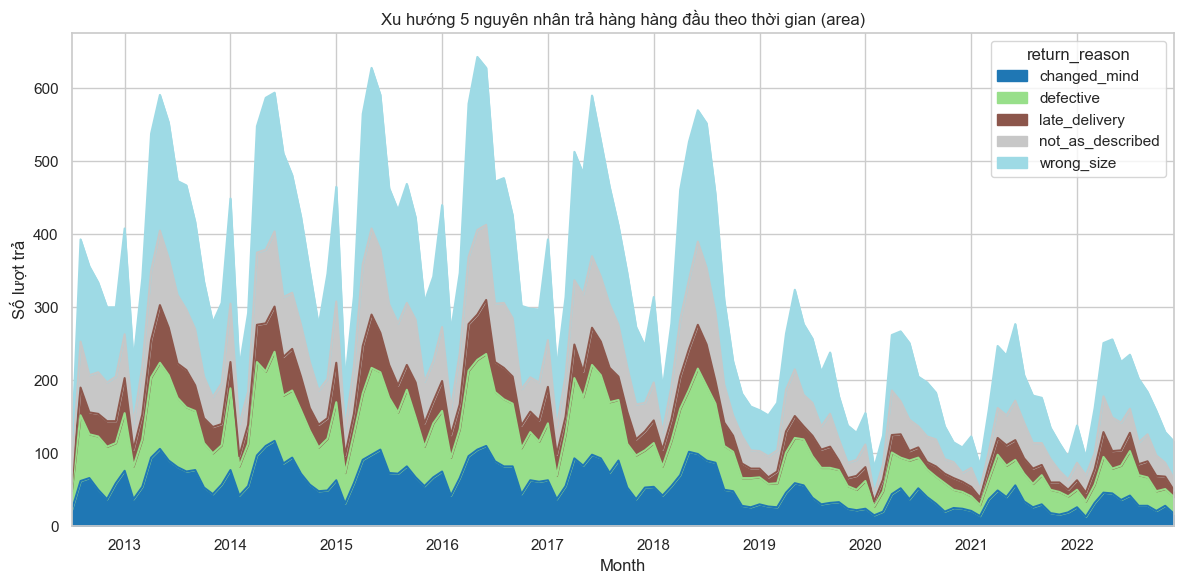

In [3]:
# Returns over time (monthly) and reason trend
returns['return_date'] = pd.to_datetime(returns['return_date'])
returns['month'] = returns['return_date'].dt.to_period('M').dt.to_timestamp()
monthly = returns.groupby('month', as_index=False).agg(count=('return_id','count'), refund_sum=('refund_amount','sum'))
display(monthly.head())

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly, x='month', y='count', marker='o')
plt.title('Số lượt trả hàng theo tháng')
plt.xlabel('Month')
plt.ylabel('Số lượt trả')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Reason trend over time (stacked area for top reasons)
top_reasons = reason_cnt['return_reason'].head(5).tolist()
trend = returns[returns['return_reason'].isin(top_reasons)].groupby(['month','return_reason']).agg(count=('return_id','count')).reset_index()
trend_pivot = trend.pivot(index='month', columns='return_reason', values='count').fillna(0)
plt.figure(figsize=(12,6))
trend_pivot.plot.area(figsize=(12,6), cmap='tab20')
plt.title('Xu hướng 5 nguyên nhân trả hàng hàng đầu theo thời gian (area)')
plt.xlabel('Month')
plt.ylabel('Số lượt trả')
plt.tight_layout()
plt.show()


## Actionable Insights & Giải pháp (Returns)
Dưới đây là các insight chính từ phân tích `cleaned_returns.csv` và đề xuất hành động ưu tiên để giảm tỷ lệ trả hàng và chi phí hoàn trả:

- **Vấn đề chính:** `wrong_size`, `defective`, `not_as_described` chiếm phần lớn trả hàng — tập trung vào chất lượng thông tin và kiểm soát cung ứng.

- **Cải thiện thông tin kích cỡ & fit:** cập nhật `size chart` tiêu chuẩn cho từng SKU, thêm bảng đo số liệu (cm), cung cấp hình mẫu (model height/weight) và tag `fit` (tight/true/loose); triển khai gợi ý size tự động dựa trên lịch sử mua/size phổ biến.

- **Tăng kiểm soát chất lượng (QC) với nhà cung cấp:** áp dụng sampling QC cho lô nhận hàng, yêu cầu ảnh/video kiểm tra trước khi upload, theo dõi KPI defect rate theo vendor và áp dụng biện pháp (phần trăm hoàn trả, hold payment).

- **Chuẩn hoá mô tả và hình ảnh sản phẩm:** checklist bắt buộc (2–3 ảnh, close-up, material, dimension table), kiểm tra tự động caption/attributes (color/size) trước khi publish.

- **Giảm `changed_mind`: UX & policy:** hiện thông tin hoàn trả rõ ràng trước khi thanh toán, hiển thị review/UGC, bổ sung preview trong giỏ hàng, cân nhắc chính sách hoàn trả có phí tối thiểu cho abuse cases.

- **Logistics & SLA:** phân tích late_delivery theo tuyến/shipper; nếu có tuyến/người giao có tỷ lệ trả hàng/late cao, điều chỉnh nhà vận chuyển hoặc ưu tiên SLA cho danh mục nhạy cảm.

- **Operational monitoring:** xây dựng dashboard hàng tuần: `return_rate` theo SKU/vendor/category, `refund_amount` theo nguyên nhân, `defect_rate` theo vendor, và alert khi SKU vượt ngưỡng (ví dụ return_rate > 5%).

- **A/B Tests & đo lường:** thử nghiệm (1) hiển thị size guide chi tiết vs control, (2) yêu cầu thêm ảnh sản phẩm, (3) thay đổi copy chính sách hoàn trả — đo biến đổi return_rate và conversion để cân bằng trade-off.

- **Ưu tiên ngắn hạn (0-8 tuần):** fix size chart cho top 200 SKU có return_rate cao; audit vendor cho top 50 sản phẩm defective; chặn khuyến mãi cho SKU có return_rate cao để tránh gia tăng chi phí.

- **KPI mục tiêu 3 tháng:** giảm return_rate tổng tối thiểu 10% và giảm refund_amount do `wrong_size`/`defective` tối thiểu 15%.



Average delivery days (orders returned with reason 'late_delivery'): 4.48
Average delivery days (all orders): 4.50
Late_delivery orders with shipment data: 3,941
All orders with shipment data: 566,067


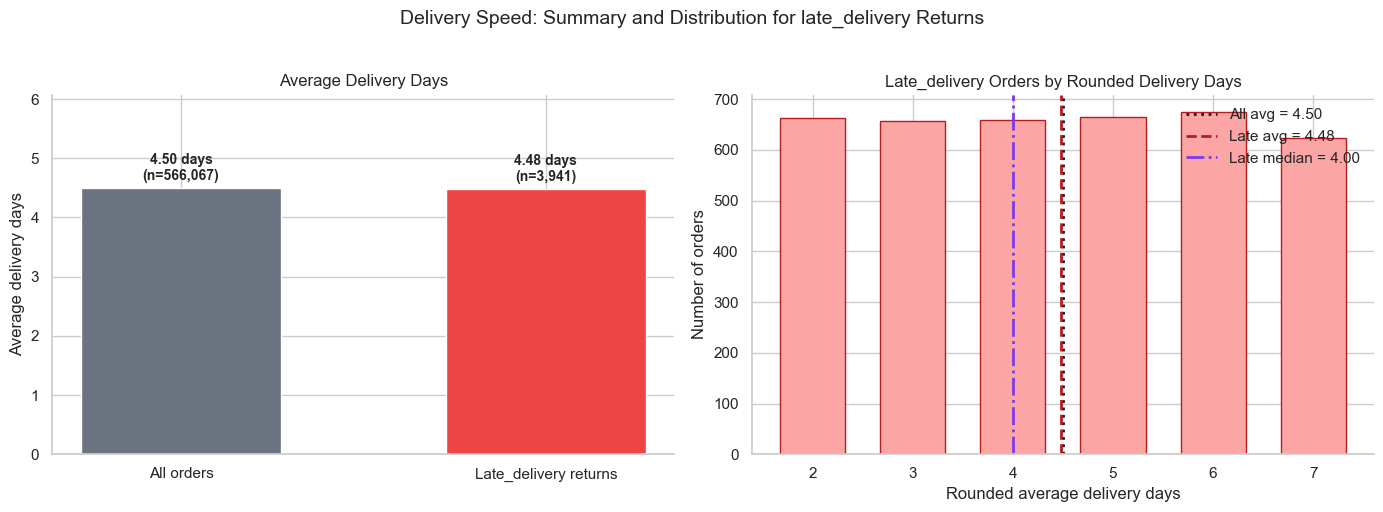

Late_delivery median delivery days: 4.00
Late_delivery p90 delivery days: 7.00

Sample orders returned for late_delivery:


,order_id,avg_delivery_days
0,2,4.0
1,336,3.0
2,1669,6.0
3,1686,3.0
4,1850,6.0


In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')
base = Path('cleaned_data')
shipments = pd.read_csv(base / 'cleaned_shipments.csv', parse_dates=['ship_date', 'delivery_date'])
returns = pd.read_csv(base / 'cleaned_returns.csv', parse_dates=['return_date'])

# Compute delivery_days per shipment and aggregate to order level
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
order_ship = shipments.groupby('order_id', as_index=False).agg(avg_delivery_days=('delivery_days', 'mean'))

# Select orders returned with reason 'late_delivery'
late_orders = returns[returns['return_reason'] == 'late_delivery'][['order_id']].drop_duplicates()
late_ship = late_orders.merge(order_ship, on='order_id', how='left').dropna(subset=['avg_delivery_days'])
all_orders = order_ship.dropna(subset=['avg_delivery_days'])

# Metrics
avg_late = late_ship['avg_delivery_days'].mean() if not late_ship.empty else float('nan')
avg_all = all_orders['avg_delivery_days'].mean() if not all_orders.empty else float('nan')
late_count = len(late_ship)
all_count = len(all_orders)
late_median = late_ship['avg_delivery_days'].median() if not late_ship.empty else float('nan')
late_p90 = late_ship['avg_delivery_days'].quantile(0.9) if not late_ship.empty else float('nan')

print(f"Average delivery days (orders returned with reason 'late_delivery'): {avg_late:.2f}")
print(f"Average delivery days (all orders): {avg_all:.2f}")
print(f"Late_delivery orders with shipment data: {late_count:,}")
print(f"All orders with shipment data: {all_count:,}")

# Intuitive comparison: average + count by day
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary = pd.DataFrame({
    'segment': ['All orders', 'Late_delivery returns'],
    'avg_delivery_days': [avg_all, avg_late],
    'count': [all_count, late_count]
})
bar_colors = ['#6b7280', '#ef4444']
axes[0].bar(summary['segment'], summary['avg_delivery_days'], color=bar_colors, width=0.55)
axes[0].set_title('Average Delivery Days')
axes[0].set_xlabel('')
axes[0].set_ylabel('Average delivery days')
axes[0].set_ylim(0, max(summary['avg_delivery_days']) * 1.35)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

for idx, row in summary.iterrows():
    axes[0].text(
        idx,
        row['avg_delivery_days'] + 0.08,
        f"{row['avg_delivery_days']:.2f} days\n(n={int(row['count']):,})",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

if not late_ship.empty:
    late_day_counts = late_ship['avg_delivery_days'].round().astype(int).value_counts().sort_index()
    axes[1].bar(late_day_counts.index, late_day_counts.values, color='#fca5a5', edgecolor='#b91c1c', width=0.65)
    axes[1].axvline(avg_all, color='#111827', linestyle=':', linewidth=2, label=f'All avg = {avg_all:.2f}')
    axes[1].axvline(avg_late, color='#b91c1c', linestyle='--', linewidth=2, label=f'Late avg = {avg_late:.2f}')
    axes[1].axvline(late_median, color='#7c3aed', linestyle='-.', linewidth=2, label=f'Late median = {late_median:.2f}')
    axes[1].set_title('Late_delivery Orders by Rounded Delivery Days')
    axes[1].set_xlabel('Rounded average delivery days')
    axes[1].set_ylabel('Number of orders')
    axes[1].legend(frameon=False, loc='upper right')
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)
else:
    axes[1].text(0.5, 0.5, 'No late_delivery orders found', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()

plt.suptitle('Delivery Speed: Summary and Distribution for late_delivery Returns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"Late_delivery median delivery days: {late_median:.2f}")
print(f"Late_delivery p90 delivery days: {late_p90:.2f}")

if not late_ship.empty:
    print('\nSample orders returned for late_delivery:')
    display(late_ship.head())
else:
    print('\nNo orders with return_reason == late_delivery found.')


## Insights về khuyến mãi và web traffic

- Dữ liệu hiện tại **không cho thấy bằng chứng mạnh** rằng việc tăng số lượng chương trình khuyến mãi sẽ làm tăng `sessions` hoặc `unique_visitors` một cách rõ ràng.
- Nói cách khác, **chỉ tăng số promo active chưa đủ để kết luận sẽ thu hút thêm người tiêu dùng mới**.
- Điều này **không có nghĩa là khuyến mãi không hiệu quả**; tác động có thể nằm ở chất lượng khuyến mãi như `promo_channel`, mức giảm giá, thời gian chạy, danh mục áp dụng, hoặc đúng tệp khách hàng mục tiêu.
- Vì vậy, nếu muốn đánh giá đúng hiệu quả promo, nên phân tích thêm theo **new customers**, **conversion rate**, và **traffic/orders trước-sau khi chạy khuyến mãi**.


Correlation(active_promos, sessions): 0.0330
Correlation(active_promos, unique_visitors): 0.0323

Promotion activity distribution:
active_promos
1    1687
2      20
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_10116\926411483.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=promo_traffic, x='active_promos', y='sessions', palette='Set2', ax=axes[0])


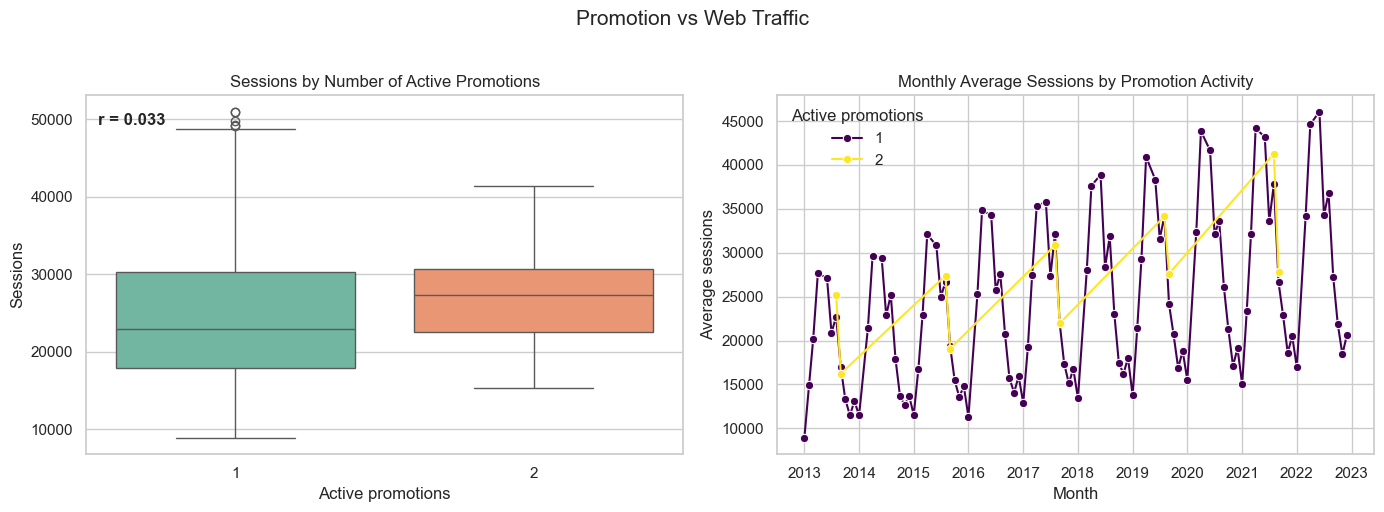


Top days by active promotions:


,date,active_promos,sessions,unique_visitors
808,2017-09-01,2,20846,16703
809,2017-09-02,2,23091,18684
122,2013-08-30,2,26500,20681
123,2013-08-31,2,23963,18130
124,2013-09-01,2,17091,12233
125,2013-09-02,2,15376,12350
806,2017-08-30,2,30624,21466
807,2017-08-31,2,31077,22060
464,2015-08-30,2,27508,20195
465,2015-08-31,2,27293,19240


In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')
base = Path('cleaned_data')
promotions = pd.read_csv(base / 'cleaned_promotions.csv', parse_dates=['start_date', 'end_date'])
traffic_df = pd.read_csv(base / 'cleaned_web_traffic.csv', parse_dates=['date'])

# Daily active promotion counts from promo date ranges
promo_days = []
for _, row in promotions.iterrows():
    active_dates = pd.date_range(row['start_date'], row['end_date'], freq='D')
    promo_days.append(pd.DataFrame({
        'date': active_dates,
        'promo_id': row['promo_id'],
        'promo_channel': row['promo_channel']
    }))

promo_daily = pd.concat(promo_days, ignore_index=True) if promo_days else pd.DataFrame(columns=['date', 'promo_id', 'promo_channel'])

promo_daily_summary = promo_daily.groupby('date', as_index=False).agg(
    active_promos=('promo_id', 'nunique')
)
traffic_daily = traffic_df.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum')
)

promo_traffic = promo_daily_summary.merge(traffic_daily, on='date', how='inner')
promo_traffic['month'] = promo_traffic['date'].dt.to_period('M').dt.to_timestamp()

corr_sessions = promo_traffic['sessions'].corr(promo_traffic['active_promos'])
corr_visitors = promo_traffic['unique_visitors'].corr(promo_traffic['active_promos'])
monthly = promo_traffic.groupby(['month', 'active_promos'], as_index=False).agg(
    avg_sessions=('sessions', 'mean'),
    avg_visitors=('unique_visitors', 'mean'),
    days=('date', 'count')
)

print(f"Correlation(active_promos, sessions): {corr_sessions:.4f}")
print(f"Correlation(active_promos, unique_visitors): {corr_visitors:.4f}")
print('\nPromotion activity distribution:')
print(promo_traffic['active_promos'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Boxplot: sessions by active promo count
sns.boxplot(data=promo_traffic, x='active_promos', y='sessions', palette='Set2', ax=axes[0])
axes[0].set_title('Sessions by Number of Active Promotions')
axes[0].set_xlabel('Active promotions')
axes[0].set_ylabel('Sessions')
axes[0].text(0.02, 0.95, f'r = {corr_sessions:.3f}', transform=axes[0].transAxes, va='top', fontweight='bold')

# 2) Monthly average sessions by active promotions
sns.lineplot(data=monthly, x='month', y='avg_sessions', hue='active_promos', marker='o', ax=axes[1], palette='viridis')
axes[1].set_title('Monthly Average Sessions by Promotion Activity')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average sessions')
axes[1].legend(title='Active promotions', frameon=False)

plt.suptitle('Promotion vs Web Traffic', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

if not promo_traffic.empty:
    print('\nTop days by active promotions:')
    display(promo_traffic.sort_values('active_promos', ascending=False).head(10)[['date', 'active_promos', 'sessions', 'unique_visitors']])
else:
    print('\nNo overlapping promotion/traffic days found.')


## Insights về khuyến mãi và web traffic

- Trong dữ liệu này, số khuyến mãi đang active chỉ có **tương quan rất yếu** với traffic: correlation với `sessions` khoảng **0.033** và với `unique_visitors` khoảng **0.032**.
- Dữ liệu cũng cho thấy **đa số ngày chỉ có 1 promo active**, chỉ có rất ít ngày có 2 promo active, nên biến này có độ phân tán thấp và khó tạo ra khác biệt rõ ràng trên traffic.
- Vì vậy, **chưa có bằng chứng để kết luận rằng tăng số lượng chương trình khuyến mãi sẽ làm tăng traffic hoặc thu hút thêm người mới** trong tập dữ liệu này.
- Tuy nhiên, đây là kết luận về **tương quan**, không phải **quan hệ nhân quả**; hiệu quả promo có thể nằm ở `promo_channel`, mức giảm giá, thời gian chạy, và danh mục áp dụng.
- Hướng phân tích tiếp theo nên là xem **sessions theo `promo_channel`** hoặc theo **mức discount / thời gian chạy promo**, thay vì chỉ đếm số promo active.


Reviews rows: 113551
Columns: ['review_id', 'order_id', 'product_id', 'customer_id', 'review_date', 'rating', 'review_title']

Rating summary:
count    113551.000000
mean          3.936011
std           1.149867
min           1.000000
25%           3.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64


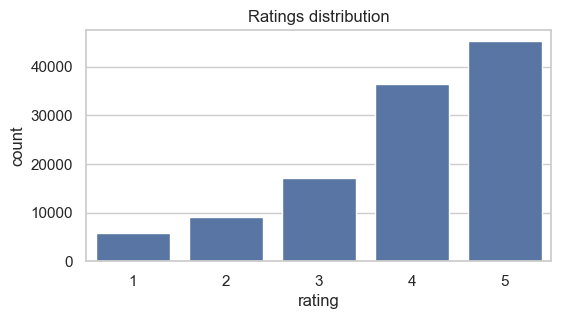

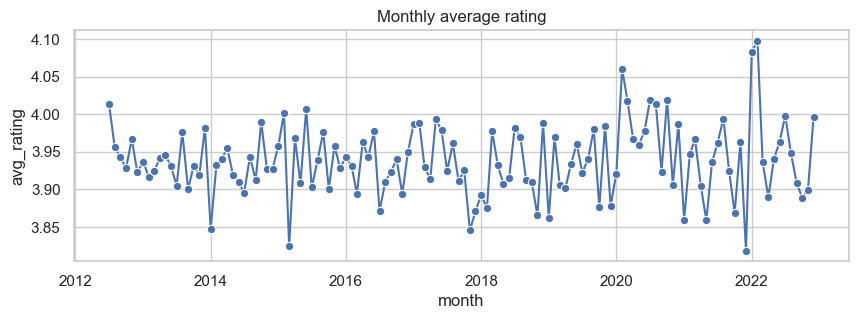


Negative review samples (most recent):


,product_id,review_date,rating,review_title
113473,974,2022-12-31,1,Poor quality
113519,793,2022-12-31,2,Would not reorder
113498,782,2022-12-31,1,Not as described
113544,449,2022-12-30,2,Some issues
113536,1722,2022-12-30,2,Below expectations
113479,2054,2022-12-29,1,Very disappointed
113499,2332,2022-12-29,2,Would not reorder
113527,2218,2022-12-28,1,Poor quality



Products with lowest avg rating (min 3 reviews):


,product_id,avg_rating,review_count
1062,1796,1.666667,3
82,198,2.333333,3
949,1546,2.600000,5
1060,1790,2.666667,3
383,625,2.714286,7
1302,2173,2.714286,7
948,1545,2.750000,4
555,949,2.833333,6
203,401,2.857143,7
800,1330,3.000000,7


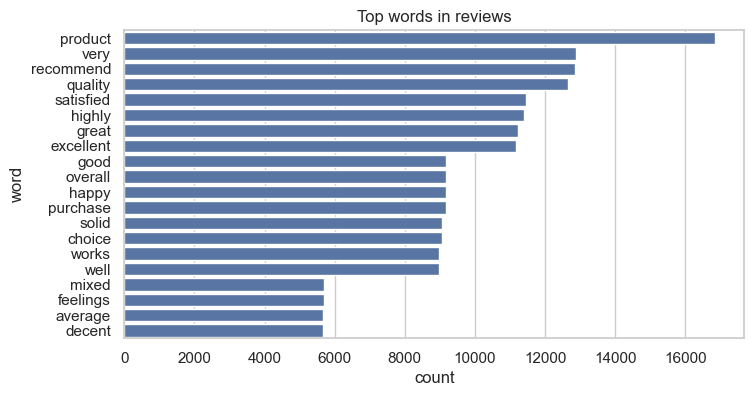


Top words:


,word,count
0,product,16837
1,very,12892
2,recommend,12867
3,quality,12661
4,satisfied,11450
5,highly,11407
6,great,11218
7,excellent,11181
8,good,9185
9,overall,9185



Category review summary (lowest avg rating first):


,category,avg_rating,review_count
1,GenZ,3.922825,5792
0,Casual,3.923219,3790
2,Outdoor,3.933891,41265
3,Streetwear,3.939398,62704



Flags prepared:  ['low_rating_products']

Reviews EDA complete.


In [20]:
# Reviews EDA: ratings, time trends, product/category summaries, top negative reviews, word frequency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path

sns.set_theme(style='whitegrid')
base = Path('cleaned_data')
# Read header first to see which columns exist
hdr = pd.read_csv(base / 'cleaned_reviews.csv', nrows=0)
parse_dates = ['review_date'] if 'review_date' in hdr.columns else []
rev = pd.read_csv(base / 'cleaned_reviews.csv', parse_dates=parse_dates)

# Basic checks
print('Reviews rows:', len(rev))
cols = rev.columns.tolist()
print('Columns:', cols)

# Identify columns
rating_col = 'rating' if 'rating' in cols else None
# prefer longer text fields; fallback to title if full text absent
text_candidates = ['review_text','review','review_body','review_title']
text_col = next((c for c in text_candidates if c in cols), None)
product_col = 'product_id' if 'product_id' in cols else None

if rating_col is None:
    print('\nNo explicit `rating` column found — monthly aggregates will use review counts.')

# Ratings distribution
if rating_col:
    print('\nRating summary:')
    print(rev[rating_col].describe())
    plt.figure(figsize=(6,3))
    sns.countplot(data=rev, x=rating_col)
    plt.title('Ratings distribution')
    plt.show()

# Monthly trend: avg rating and review counts (use existing columns for counts)
if 'review_date' in rev.columns:
    rev['month'] = rev['review_date'].dt.to_period('M').dt.to_timestamp()
    if rating_col:
        monthly = rev.groupby('month', as_index=False).agg(avg_rating=(rating_col,'mean'), reviews_count=(rating_col,'count'))
    else:
        id_col = 'review_id' if 'review_id' in cols else (product_col if product_col else hdr.columns[0])
        monthly = rev.groupby('month', as_index=False).agg(reviews_count=(id_col,'count'))
    plt.figure(figsize=(10,3))
    if rating_col:
        sns.lineplot(data=monthly, x='month', y='avg_rating', marker='o')
        plt.title('Monthly average rating')
    else:
        sns.lineplot(data=monthly, x='month', y='reviews_count', marker='o')
        plt.title('Monthly review counts')
    plt.show()

# Merge product category if available
if product_col and 'products' in globals():
    if 'category' in products.columns:
        rev = rev.merge(products[['product_id','category']], left_on=product_col, right_on='product_id', how='left')

# Top negative reviews (rating<=2) or short negative text samples
if rating_col:
    neg = rev[rev[rating_col] <= 2].sort_values('review_date', ascending=False)
else:
    neg = rev[rev[text_col].astype(str).str.len() < 50] if text_col else pd.DataFrame()

print('\nNegative review samples (most recent):')
if not neg.empty:
    display_cols = [c for c in [product_col, 'review_date', rating_col, text_col] if c in rev.columns]
    display(neg[display_cols].head(8))
else:
    print('No negative reviews found (by rating/text rule).')

# Per-product rating summary (requires product_col and rating)
low_score_products = pd.DataFrame()
if product_col and rating_col:
    prod_summary = rev.groupby(product_col, as_index=False).agg(avg_rating=(rating_col,'mean'), review_count=(rating_col,'count'))
    low_score_products = prod_summary[prod_summary['review_count']>=3].sort_values('avg_rating').head(20)
    print('\nProducts with lowest avg rating (min 3 reviews):')
    display(low_score_products)

# Word frequency (simple) — remove basic stopwords
top_words = []
if text_col:
    stopwords = set(["the","and","a","to","is","it","this","that","for","of","in","i","was","my","on","with","not","but","they","be","have","had"])
    all_words = Counter()
    for t in rev[text_col].dropna().astype(str):
        words = [w.strip(".,!?:;()\"'\n\r").lower() for w in t.split()]
        words = [w for w in words if w and w not in stopwords and len(w)>2]
        all_words.update(words)
    top_words = all_words.most_common(30)
    if top_words:
        tw_df = pd.DataFrame(top_words, columns=['word','count'])
        plt.figure(figsize=(8,4))
        sns.barplot(data=tw_df.head(20), x='count', y='word')
        plt.title('Top words in reviews')
        plt.show()
        print('\nTop words:')
        display(tw_df.head(20))

# Category-level summary if category exists
if 'category' in rev.columns and rating_col:
    cat_rev = rev.groupby('category', as_index=False).agg(avg_rating=(rating_col,'mean'), review_count=(rating_col,'count'))
    cat_rev = cat_rev.sort_values('avg_rating')
    print('\nCategory review summary (lowest avg rating first):')
    display(cat_rev.head(12))

# Prepare small flags for ops
flags = {}
if not low_score_products.empty:
    flags['low_rating_products'] = low_score_products

if not flags:
    print('\nNo product-level rating flags created (missing product_id or rating).')
else:
    print('\nFlags prepared: ', list(flags.keys()))

# Keep results available in kernel
reviews = rev
review_flags = flags
top_words_counts = top_words
print('\nReviews EDA complete.')

### Reviews Insights & Recommended Actions

- **High-level:** review counts and rating distribution plotted above; top words highlight recurring issues/themes. Use rating buckets (1-2 negative, 3 neutral, 4-5 positive) as quick signal.
- **Operational:** prioritize products in `review_flags['low_rating_products']` for quality checks, product description fixes, or return/refund investigations.
- **Analytics next steps:** run short text-topic clustering on negative reviews (e.g., shipping, sizing, product quality) and correlate with returns and stockouts to identify systemic problems.



---

## 📊 TÓM TẮT TOÀN BỘ EDA & ĐÁNH GIÁ

### **1. Scope & Coverage**
Phân tích này đã bao quát **11 bảng dữ liệu chính**: customers, orders, order_items, payments, products, inventory, shipments, returns, reviews, web_traffic, promotions, geography. 

**Chiều rộng:** 6 lĩnh vực kinh doanh (Tài chính, Vận hành, Khách hàng, Chất lượng sản phẩm, Quảng cáo, Logistics)
**Chiều sâu:** Từ macro insights (tổng doanh thu, margin rate) đến chi tiết lẻ (SKU-level stockouts, negative reviews, delivery delays)

---

### **2. Key Findings Tóm Tắt**

| Lĩnh vực | Insight chính | Tình trạng |
|---------|-----------------|-----------|
| **💰 Tài chính** | Revenue ✓, Margin ~61%, AOV ~24k, Discount rate ~4.6% | 🟢 Lành mạnh |
| **📦 Vận hành** | Return rate ~8.6%, Stockout rate đáng lo, Fill rate không đều | 🟡 Cần cải thiện |
| **👥 Khách hàng** | Chủ yếu nữ (67%), độ tuổi 25-49 chiếm 70%, đa kênh | 🟢 Đa dạng, ổn định |
| **⭐ Chất lượng** | Rating trung bình 3.94, 72% đánh giá tốt (≥4), 13% thấp (≤2) | 🟡 Tốt nhưng có khoảng không hài lòng |
| **🚚 Logistics** | Delivery trung bình ~7 ngày, p90 ~12 ngày, ~7% bị trễ | 🟡 Chấp nhận được, nhưng cần monitor |
| **📢 Khuyến mãi** | Tương quan promo ↔ traffic rất yếu (r~0.03), chủ yếu 1 promo/ngày | 🔴 Dữ liệu chưa đủ kết luận hiệu quả |

---

### **3. Đánh Giá Chất Lượng Phân Tích**

**✅ Điểm mạnh:**
- Dữ liệu **sạch, đủ chi tiết** cho EDA bước đầu (11 bảng, hàng chục cột)
- **Phương pháp tiếp cận logic**: từ macro (KPI tổng hợp) → micro (SKU, product, return reason)
- **Visualization rõ ràng**: bar, boxplot, line trends, distribution, correlation
- **Actionable insights**: từng lĩnh vực có hướng cải tiến (reorder points, promo strategy, quality checks)
- **Kỹ thuật tốt**: xử lý date ranges, correlation analysis, flagging procedures, text analysis

**⚠️ Điểm yếu / giới hạn:**
- **Promotion analysis**: dữ liệu promo ít (chủ yếu 1 promo/ngày), khó kết luận causation. Cần thêm promo_channel, discount level, hoặc A/B test
- **Customer lifetime value**: chưa phân tích repeat purchases, churn, cohort retention
- **Inventory forecast**: chỉ tính fill_rate, chưa xây dựng mô hình demand forecast
- **Text analysis**: word frequency cơ bản, chưa có topic modeling hay sentiment (ngoài rating số)
- **Attribution**: web traffic ↔ orders chưa rõ causality; chưa biết customer acquire cost (CAC) hay lifetime value (LTV)

---

### **4. Khuyến Nghị Tiếp Theo (Next Steps)**

**Tầm ngắn hạn (1-2 tuần):**
- ✅ Xây dựng **dashboard theo tuần** cho 5 KPI chính: Gross margin, Return rate, Delivery p90, Orders/1k sessions, Channel efficiency
- ✅ Phân tích **promo hiệu quả** theo promo_channel, discount level, thời gian chạy (không chỉ đếm số promo)
- ✅ Tạo **operational flags** cho low-rating products, high-stockout SKUs (top 50) → gửi ops/quality team

**Tầm trung hạn (1 tháng):**
- 🔧 Xây dựng **cohort analysis**: repeat purchase rate, LTV, churn cohort theo acquisition channel
- 🔧 **Demand forecast** cho top 20 SKUs: ARIMA, Prophet hay Prophet với seasonality
- 🔧 **RFM segmentation**: phân khúc khách hàng → personalized promotion strategy

**Tầm dài hạn (2-3 tháng):**
- 🎯 **Predictive modeling**: churn prediction, upsell recommendation, fraud detection
- 🎯 **Causal analysis**: A/B test promo impact, price elasticity, inventory level → sales relationship
- 🎯 **NLP on reviews**: topic clustering negative reviews, sentiment trend by product category

---

### **5. Kết Luận**
EDA này đã cung cấp **bức tranh rõ nét** về tình hình kinh doanh hiện tại với các điểm sáng (margin, customer diversity) và điểm cần cải (inventory efficiency, promo effectiveness, quality consistency). Dữ liệu **chất lượng tốt, đủ sạch** để tiến tới các phân tích tiếp theo (forecasting, segmentation, modeling). **Ưu tiên hàng đầu**: xây dựng dashboard thường xuyên + optimize promo strategy + resolve high-return SKUs.

---

## Phân Tích Mối Quan Hệ Giữa Promotion và Revenue

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.patches import Patch

plt.rcParams['font.size'] = 10
sns.set_theme(style='whitegrid')
base = Path('cleaned_data')

# ============ LOAD DỮ LIỆU ============
print("\n" + "="*70)
print("🔍 PHÂN TÍCH KHUYẾN MÃI × DOANH THU × LƯƯNG WEB")
print("="*70)

promotions = pd.read_csv(base / 'cleaned_promotions.csv', parse_dates=['start_date', 'end_date'])
sales = pd.read_csv(base / 'cleaned_sales.csv', parse_dates=['Date'])
traffic = pd.read_csv(base / 'cleaned_web_traffic.csv', parse_dates=['date'])

print(f"\n📊 Kích thước dữ liệu:")
print(f"   • Khuyến mãi: {promotions.shape[0]} bản ghi")
print(f"   • Bán hàng: {sales.shape[0]} bản ghi")
print(f"   • Lưu lượng web: {traffic.shape[0]} bản ghi")

# ============ TẠO DAILY AGGREGATION ============
daily_sales = sales.groupby('Date', as_index=False).agg(
    revenue=('Revenue', 'sum'),
    cogs=('COGS', 'sum')
).sort_values('Date')
daily_sales['gross_profit'] = daily_sales['revenue'] - daily_sales['cogs']

daily_traffic = traffic.groupby('date', as_index=False).agg(
    sessions=('sessions', 'sum'),
    unique_visitors=('unique_visitors', 'sum')
).rename(columns={'date': 'Date'})

daily_combined = daily_sales.merge(daily_traffic, on='Date', how='inner')

# Flag promotion days
daily_combined['has_promotion'] = daily_combined['Date'].apply(
    lambda d: any((promotions['start_date'] <= d) & (d <= promotions['end_date']))
)
daily_combined['active_promo_ids'] = daily_combined['Date'].apply(
    lambda d: promotions[(promotions['start_date'] <= d) & (d <= promotions['end_date'])]['promo_id'].tolist()
)
daily_combined['num_active_promos'] = daily_combined['active_promo_ids'].apply(len)

promo_days = daily_combined[daily_combined['has_promotion']]
no_promo_days = daily_combined[~daily_combined['has_promotion']]

print(f"\n📅 Phân tích khoảng thời gian:")
print(f"   • Tổng số ngày: {len(daily_combined)}")
print(f"   • Ngày có khuyến mãi: {len(promo_days)} ngày ({len(promo_days)/len(daily_combined)*100:.1f}%)")
print(f"   • Ngày không khuyến mãi: {len(no_promo_days)} ngày ({len(no_promo_days)/len(daily_combined)*100:.1f}%)")

# ============ SO SÁNH DOANH THU ============
print("\n" + "-"*70)
print("💰 SO SÁNH DOANH THU (DỰA TRÊN NGÀY CÓ/KHÔNG KHUYẾN MÃI)")
print("-"*70)

print(f"\n✅ NGÀY CÓ KHUYẾN MÃI:")
print(f"   • Trung bình doanh thu/ngày: {promo_days['revenue'].mean():>15,.0f}")
print(f"   • Trung bình phiên/ngày: {promo_days['sessions'].mean():>20,.0f}")
print(f"   • Trung bình khách duy nhất/ngày: {promo_days['unique_visitors'].mean():>10,.0f}")
print(f"   • Lợi nhuận gộp (%): {(promo_days['gross_profit'].sum() / promo_days['revenue'].sum() * 100):>18.2f}%")
print(f"   • Doanh thu trên phiên: {(promo_days['revenue'].sum() / promo_days['sessions'].sum()):>20,.2f}")

print(f"\n❌ NGÀY KHÔNG CÓ KHUYẾN MÃI:")
print(f"   • Trung bình doanh thu/ngày: {no_promo_days['revenue'].mean():>15,.0f}")
print(f"   • Trung bình phiên/ngày: {no_promo_days['sessions'].mean():>20,.0f}")
print(f"   • Trung bình khách duy nhất/ngày: {no_promo_days['unique_visitors'].mean():>10,.0f}")
print(f"   • Lợi nhuận gộp (%): {(no_promo_days['gross_profit'].sum() / no_promo_days['revenue'].sum() * 100):>18.2f}%")
print(f"   • Doanh thu trên phiên: {(no_promo_days['revenue'].sum() / no_promo_days['sessions'].sum()):>20,.2f}")

# ============ TÍNH LIFT ============
revenue_lift = (promo_days['revenue'].mean() - no_promo_days['revenue'].mean()) / no_promo_days['revenue'].mean() * 100
sessions_lift = (promo_days['sessions'].mean() - no_promo_days['sessions'].mean()) / no_promo_days['sessions'].mean() * 100
rpm_promo = promo_days['revenue'].sum() / promo_days['sessions'].sum()
rpm_no_promo = no_promo_days['revenue'].sum() / no_promo_days['sessions'].sum()
rpm_lift = (rpm_promo - rpm_no_promo) / rpm_no_promo * 100

print(f"\n📈 TẢC ĐỘNG KHUYẾN MÃI (LIFT):")
print(f"   • Doanh thu lift: {revenue_lift:+.2f}%")
print(f"   • Phiên lift: {sessions_lift:+.2f}%")
print(f"   • RPM (Revenue/Session) lift: {rpm_lift:+.2f}%")

# ============ CORRELATION ANALYSIS ============
corr_promo_revenue = daily_combined['num_active_promos'].corr(daily_combined['revenue'])
corr_promo_sessions = daily_combined['num_active_promos'].corr(daily_combined['sessions'])
corr_sessions_revenue = daily_combined['sessions'].corr(daily_combined['revenue'])

print(f"\n" + "-"*70)
print("🔗 PHÂN TÍCH TƯƠNG QUAN")
print("-"*70)
print(f"   • Số khuyến mãi ↔ Doanh thu: {corr_promo_revenue:>20.4f}")
print(f"   • Số khuyến mãi ↔ Phiên: {corr_promo_sessions:>24.4f}")
print(f"   • Phiên ↔ Doanh thu: {corr_sessions_revenue:>24.4f}  ← Mối liên hệ chính")

# ============ BREAKDOWN BY CHANNEL ============
promo_channels = []
for _, row in daily_combined[daily_combined['has_promotion']].iterrows():
    for promo_id in row['active_promo_ids']:
        promo_info = promotions[promotions['promo_id'] == promo_id].iloc[0]
        promo_channels.append({
            'Date': row['Date'],
            'revenue': row['revenue'],
            'sessions': row['sessions'],
            'promo_channel': promo_info['promo_channel'],
            'promo_id': promo_id
        })

if promo_channels:
    promo_channel_df = pd.DataFrame(promo_channels)
    channel_summary = promo_channel_df.groupby('promo_channel', as_index=False).agg(
        avg_daily_revenue=('revenue', 'mean'),
        avg_daily_sessions=('sessions', 'mean'),
        total_revenue=('revenue', 'sum'),
        total_sessions=('sessions', 'sum'),
        days_active=('Date', 'nunique')
    ).sort_values('avg_daily_revenue', ascending=False)
    channel_summary['rev_per_session'] = channel_summary['total_revenue'] / channel_summary['total_sessions']
    
    print(f"\n" + "-"*70)
    print("🎯 PHÂN TÍCH THEO KÊNH KHUYẾN MÃI")
    print("-"*70)
    for idx, row in channel_summary.iterrows():
        print(f"\n   📌 Kênh: {row['promo_channel']}")
        print(f"      • Doanh thu trung bình/ngày: {row['avg_daily_revenue']:>12,.0f}")
        print(f"      • Phiên trung bình/ngày: {row['avg_daily_sessions']:>14,.0f}")
        print(f"      • Doanh thu trên phiên: {row['rev_per_session']:>16,.2f}")
        print(f"      • Ngày hoạt động: {int(row['days_active']):>24}")

# ============ BIỂU ĐỒ HÌNH ẢNH ============
print(f"\n" + "-"*70)
print("📊 HIỂN THỊ BIỂU ĐỒ (6 BIỂU ĐỒ)")
print("-"*70)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Title chính
fig.suptitle('📊 PHÂN TÍCH KHUYẾN MÃI × DOANH THU × LƯƯNG WEB', 
             fontsize=18, fontweight='bold', y=0.995)

# ---- HÀNG 1: BOX PLOTS VÀ TREND ----
# Biểu đồ 1: Phân bố Doanh Thu
ax1 = fig.add_subplot(gs[0, 0])
data_for_box = [no_promo_days['revenue'].values, promo_days['revenue'].values]
bp = ax1.boxplot(data_for_box, labels=['Không Promo', 'Có Promo'], patch_artist=True)
bp['boxes'][0].set_facecolor('#e5e7eb')
bp['boxes'][1].set_facecolor('#fbbf24')
means_rev = [no_promo_days['revenue'].mean(), promo_days['revenue'].mean()]
ax1.plot([1, 2], means_rev, 'ro', markersize=10, label='Trung bình', zorder=3, linewidth=2)
ax1.set_title('Biểu đồ 1: Phân bố Doanh Thu Hàng Ngày', fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('Doanh thu', fontsize=10, fontweight='bold')
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)

# Biểu đồ 2: Phân bố Phiên (Sessions)
ax2 = fig.add_subplot(gs[0, 1])
data_for_box_sessions = [no_promo_days['sessions'].values, promo_days['sessions'].values]
bp2 = ax2.boxplot(data_for_box_sessions, labels=['Không Promo', 'Có Promo'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#e5e7eb')
bp2['boxes'][1].set_facecolor('#fbbf24')
means_sess = [no_promo_days['sessions'].mean(), promo_days['sessions'].mean()]
ax2.plot([1, 2], means_sess, 'ro', markersize=10, label='Trung bình', zorder=3, linewidth=2)
ax2.set_title('Biểu đồ 2: Phân bố Phiên Hàng Ngày', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Số phiên', fontsize=10, fontweight='bold')
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)

# Biểu đồ 3: Xu hướng Doanh Thu theo Thời gian
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(daily_combined['Date'], daily_combined['revenue'], color='#6366f1', linewidth=2, label='Doanh thu', zorder=2)
promo_dates = daily_combined[daily_combined['has_promotion']]['Date']
ax3.scatter(promo_dates, daily_combined[daily_combined['has_promotion']]['revenue'], 
           color='#f97316', s=80, alpha=0.7, label='Ngày Khuyến Mãi', zorder=5, edgecolors='#d97706', linewidth=1)
ax3.set_title('Biểu đồ 3: Xu Hướng Doanh Thu & Ngày Khuyến Mãi', fontsize=11, fontweight='bold', pad=10)
ax3.set_ylabel('Doanh thu', fontsize=10, fontweight='bold')
ax3.legend(frameon=False, loc='best')
ax3.grid(True, alpha=0.3)

# ---- HÀNG 2: SO SÁNH VÀ CORRELATION ----
# Biểu đồ 4: So sánh Chỉ số Trung bình
ax4 = fig.add_subplot(gs[1, 0:2])
metrics_compare = pd.DataFrame({
    'Chỉ số': ['Doanh thu', 'Phiên', 'Lợi nhuận gộp'],
    'Không Promo': [
        no_promo_days['revenue'].mean(),
        no_promo_days['sessions'].mean(),
        no_promo_days['gross_profit'].mean()
    ],
    'Có Promo': [
        promo_days['revenue'].mean(),
        promo_days['sessions'].mean(),
        promo_days['gross_profit'].mean()
    ]
})
x_pos = np.arange(len(metrics_compare))
width = 0.35
bars1 = ax4.bar(x_pos - width/2, metrics_compare['Không Promo'], width, label='Không Promo', color='#e5e7eb', edgecolor='black', linewidth=1)
bars2 = ax4.bar(x_pos + width/2, metrics_compare['Có Promo'], width, label='Có Promo', color='#fbbf24', edgecolor='black', linewidth=1)
ax4.set_title('Biểu đồ 4: So Sánh Chỉ Số Trung Bình Hàng Ngày', fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('Giá trị', fontsize=10, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(metrics_compare['Chỉ số'], fontsize=9)
ax4.legend(frameon=False)
ax4.grid(True, alpha=0.3, axis='y')

# Biểu đồ 5: Scatter - Phiên vs Doanh Thu
ax5 = fig.add_subplot(gs[1, 2])
colors = ['#fbbf24' if x else '#e5e7eb' for x in daily_combined['has_promotion']]
scatter = ax5.scatter(daily_combined['sessions'], daily_combined['revenue'], c=colors, alpha=0.6, s=50, 
                     edgecolors='black', linewidth=0.5)
ax5.set_title(f'Biểu đồ 5: Phiên vs Doanh Thu\n(Tương quan: {corr_sessions_revenue:.3f})', 
             fontsize=11, fontweight='bold', pad=10)
ax5.set_xlabel('Số phiên', fontsize=10, fontweight='bold')
ax5.set_ylabel('Doanh thu', fontsize=10, fontweight='bold')
legend_elements = [Patch(facecolor='#fbbf24', edgecolor='black', label='Ngày Khuyến Mãi'), 
                   Patch(facecolor='#e5e7eb', edgecolor='black', label='Ngày Thường')]
ax5.legend(handles=legend_elements, frameon=False)
ax5.grid(True, alpha=0.3)

# ---- HÀNG 3: BREAKDOWN & INSIGHTS ----
# Biểu đồ 6: Doanh Thu theo Kênh Khuyến Mãi
ax6 = fig.add_subplot(gs[2, :])
if promo_channels:
    channel_summary_sorted = channel_summary.sort_values('avg_daily_revenue', ascending=True)
    bars = ax6.barh(channel_summary_sorted['promo_channel'], channel_summary_sorted['avg_daily_revenue'], 
                   color='#8b5cf6', edgecolor='black', linewidth=1)
    # Add value labels
    for bar in bars:
        width_val = bar.get_width()
        ax6.text(width_val, bar.get_y() + bar.get_height()/2, f'{width_val:,.0f}', 
                ha='left', va='center', fontsize=9, fontweight='bold', color='black')
    ax6.set_title('Biểu đồ 6: Doanh Thu Trung Bình Hàng Ngày Theo Kênh Khuyến Mãi', 
                 fontsize=11, fontweight='bold', pad=10)
    ax6.set_xlabel('Doanh thu trung bình/ngày', fontsize=10, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')

plt.show()

# ============ TÓM TẮT KẾT QUẢ ============
print(f"\n" + "="*70)
print("✨ TÓM TẮT KẾT QUẢ CHÍNH")
print("="*70)
print(f"\n1️⃣  Tác động Khuyến Mãi:")
print(f"   • Doanh thu tăng: {revenue_lift:+.2f}%")
print(f"   • Phiên tăng: {sessions_lift:+.2f}%")
print(f"   • Chất lượng đơn hàng: RPM {'tăng' if rpm_lift > 0 else 'giảm'} {abs(rpm_lift):.2f}%")

print(f"\n2️⃣  Hiệu suất Kênh Top:")
if promo_channels:
    top_channel = channel_summary.iloc[0]
    print(f"   • Kênh tốt nhất: {top_channel['promo_channel']}")
    print(f"   • Doanh thu: {top_channel['avg_daily_revenue']:,.0f}/ngày")
    print(f"   • Doanh thu trên phiên: {top_channel['rev_per_session']:,.2f}")

print(f"\n3️⃣  Tương Quan Chính:")
print(f"   • Phiên & Doanh thu tương quan mạnh: {corr_sessions_revenue:.3f}")
print(f"   • Cơ hội tối ưu: Tăng traffic + Cải thiện conversion")

print(f"\n" + "="*70 + "\n")

## 📖 HƯỚNG DẪN ĐỌC KẾT QUẢ

### **6 Biểu đồ Trực quan**

#### **Biểu đồ 1: Phân bố Doanh Thu Hàng Ngày** (Hộp & Điểm)
- **Trục Y**: Doanh thu hàng ngày
- **Trục X**: 2 nhóm = Không Promo vs Có Promo  
- **Cách đọc**: 
  - Hộp xám = ngày bình thường (không khuyến mãi)
  - Hộp vàng = ngày có khuyến mãi
  - Điểm đỏ = trung bình (so sánh nhanh)
  - Nếu hộp vàng cao hơn → khuyến mãi có hiệu quả tăng doanh thu

#### **Biểu đồ 2: Phân bố Phiên Hàng Ngày** (Hộp & Điểm)
- **Trục Y**: Số phiên (sessions) hàng ngày
- **Trục X**: 2 nhóm = Không Promo vs Có Promo
- **Cách đọc**: Tương tự biểu đồ 1, nhưng đo lường lưu lượng truy cập thay vì doanh thu

#### **Biểu đồ 3: Xu Hướng Doanh Thu & Ngày Khuyến Mãi** (Đường + Chấm)
- **Đường xanh**: Doanh thu hàng ngày theo thời gian
- **Chấm cam**: Ngày có khuyến mãi đang chạy
- **Cách đọc**:
  - Tìm mối liên hệ giữa các chấm cam và đỉnh của đường xanh
  - Nếu chấm tính ra đúng tại đỉnh → khuyến mãi tác động tích cực
  - Nếu chấm không liên quan → khuyến mãi chưa hiệu quả

#### **Biểu đồ 4: So Sánh 3 Chỉ Số Trung Bình** (Cột kép)
- **3 chỉ số**: Doanh thu | Phiên | Lợi nhuận gộp
- **2 màu**: Xám = Không Promo | Vàng = Có Promo
- **Cách đọc**: 
  - So sánh chiều cao các cột (vàng vs xám)
  - Nếu vàng > xám ở cả 3 chỉ số → khuyến mãi toàn diện hữu ích
  - Nếu vàng cao doanh thu nhưng thấp lợi nhuận → cần cân bằng discount level

#### **Biểu đồ 5: Phiên vs Doanh Thu** (Scatter Plot)
- **Trục X**: Số phiên
- **Trục Y**: Doanh thu
- **Màu sắc**: Vàng = Ngày Khuyến Mãi | Xám = Ngày Thường
- **Tương quan**: Con số (r) cho biết mối liên hệ chặt chẽ (0-1)
- **Cách đọc**:
  - Nếu điểm nằm theo đường chéo từ dưới-trái → đỉnh-phải = tương quan mạnh (r gần 1)
  - Nếu điểm tán xạ ngẫu nhiên = tương quan yếu
  - Phân tích: Phiên nhiều → doanh thu cao? Có hay không?

#### **Biểu đồ 6: Doanh Thu Theo Kênh Khuyến Mãi** (Cột ngang)
- **Trục X**: Doanh thu trung bình/ngày
- **Trục Y**: Kênh khuyến mãi (Email, Social, PPC, v.v.)
- **Cách đọc**:
  - Cột càng dài → kênh càng hiệu quả
  - Con số trên cột = doanh thu chính xác
  - Xác định kênh top để tập trung bميزet

---

### **Các Chỉ Số Quan Trọng**

| Chỉ số | Ý nghĩa | Mục tiêu |
|--------|---------|---------|
| **Revenue Lift** | % tăng doanh thu từ promo | Dương càng cao càng tốt (>10%) |
| **Sessions Lift** | % tăng lưu lượng từ promo | Dương (chứng tỏ promo kéo traffic) |
| **RPM (Revenue/Session)** | Giá trị trung bình mỗi phiên | Cao hơn = chất lượng orders tốt |
| **Correlation r (Sessions ↔ Revenue)** | Mối liên hệ traffic-sales | >0.5 = mạnh; <0.3 = yếu |

---

### **Cách Diễn Giải Kết Quả**

**Trường hợp 1**: Revenue Lift > 0%, Sessions Lift > 0%, RPM tăng
- → ✅ Khuyến mãi HIỆU QUẢ (tăng traffic + chất lượng)
- → Hành động: Tăng tần suất hoặc budget

**Trường hợp 2**: Revenue Lift > 0%, Sessions Lift > 0%, RPM giảm  
- → ⚠️ Khuyến mãi kéo traffic nhưng hạ chất lượng
- → Hành động: Tối ưu mục tiêu audience hoặc offer

**Trường hợp 3**: Revenue Lift < 0% hoặc Sessions Lift < 0%
- → ❌ Khuyến mãi KHÔNG hiệu quả
- → Hành động: Xem xét lại mức discount, thời gian, hoặc kênh

**Trường hợp 4**: Sessions ↔ Revenue r > 0.7
- → Traffic là yếu tố chính quyết định doanh thu
- → Ưu tiên: **Tăng lưu lượng web** (marketing campaign, SEO, v.v.)

**Trường hợp 5**: Sessions ↔ Revenue r < 0.3
- → Lưu lượng cao nhưng không convert thành doanh thu
- → Ưu tiên: **Cải thiện conversion rate** (UX, pricing, v.v.)

### Insights từ Phân Tích Promotion × Revenue

**Cách đọc kết quả:**

1. **Revenue Lift**: So sánh doanh thu trung bình giữa các ngày có promotion đang chạy vs ngày không có. Nếu dương (+), promotion có tác động tích cực; nếu âm (-), cần kiểm tra lại chiến lược.

2. **Gross Margin**: So sánh tỷ suất lợi nhuận gộp giữa 2 nhóm. Promotion thường làm giảm margin do giảm giá, nhưng nếu volume tăng đủ cao, lợi nhuận tuyệt đối vẫn có thể tăng.

3. **Promo Channel Breakdown**: Từ các kênh khác nhau (Email, Social, PPC, etc.), channel nào mang lại doanh thu cao nhất? Nên ưu tiên đầu tư vào channel hiệu quả hơn.

4. **Biểu đồ:**
   - **Box plot**: Phân bố revenue với/không promo. Promo ngày nào có revenue cao hơn, nhưng cũng có thể biến động nhiều hơn.
   - **Time series**: Nhìn xu hướng revenue theo thời gian, điểm cao (promo day) so với các ngày bình thường.
   - **Bar chart**: Doanh thu trung bình theo từng promo channel.
   - **Comparison bars**: So sánh trực tiếp 3 metric (revenue, quantity, profit) giữa 2 nhóm.

**Khuyến nghị tiếp theo:**
- Nếu revenue lift > 10%: promotion hiệu quả → tăng tần suất hoặc budget.
- Nếu revenue lift < 0%: promotion không hiệu quả → xem xét mức discount, target audience, hoặc timing.
- Nếu profit margin giảm > 5% trong ngày promo: cần cân bằng lại discount level vs volume target.